# Latest H5 Real Data vs CORSIKA Matching Simulated Data (15000-pulse sample)

This notebook repeats the current peak-prioritized real-vs-sim comparison workflow, but replaces the old `10min.csv` input with only the latest Test_Panel HDF5 run:

- Panel A: `03A_040526_1h50m_AMP5_C5_thr0_82.h5`
- Panel B: `03B_040526_1h50m_AMP5_C5_thr0_123.h5`

Panels are loaded and segmented separately. Set `PRIMARY_PANEL = "A"` or `"B"` for the main comparison. Panels are not silently merged.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT / "src"))

DATA_CORSIKA = PROJECT_ROOT / "data/raw/corsika/DATA_PROCESADA_ANTONIO_ROMERO.csv"
LATEST_H5_FILES = {
    "A": PROJECT_ROOT / "data/raw/Test_Panel/03A_040526_1h50m_AMP5_C5_thr0_82.h5",
    "B": PROJECT_ROOT / "data/raw/Test_Panel/03B_040526_1h50m_AMP5_C5_thr0_123.h5",
}

OUTPUT_TABLES = PROJECT_ROOT / "outputs/tables"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs/figures"
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("CORSIKA exists:", DATA_CORSIKA.exists(), DATA_CORSIKA)
for panel, path in LATEST_H5_FILES.items():
    print(f"Latest HDF5 panel {panel} exists:", path.exists(), path)


Project root: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework
CORSIKA exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\corsika\DATA_PROCESADA_ANTONIO_ROMERO.csv
Latest HDF5 panel A exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03A_040526_1h50m_AMP5_C5_thr0_82.h5
Latest HDF5 panel B exists: True C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\data\raw\Test_Panel\03B_040526_1h50m_AMP5_C5_thr0_123.h5


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from tambo_sipm import load_simulation_config
from tambo_sipm.io import (
    build_photon_events,
    detector_summary,
    estimate_sampling_interval_ns,
    format_test_panel_voltage_unit_report,
    load_romero_photon_table,
    load_test_panel_h5_samples,
    pulse_collection_to_dict,
    pulse_length_distribution,
    sampling_interval_report,
    segment_test_panel_samples,
    segment_test_panel_samples_by_threshold,
    summarize_test_panel_segmentation,
)
from tambo_sipm.analysis import (
    compare_real_sim_features,
    extract_features_from_pulse_table,
    summarize_feature_table,
)
from tambo_sipm.simulation import build_calibration_config
from tambo_sipm.simulation.batch import simulate_feature_row_from_photon_event
from tambo_sipm.detector import simulate_detector_event_from_config
from tambo_sipm.plotting import plot_waveform_overlay, save_figure

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10
print("Imports OK")


Imports OK


## 1. Parameters

The Red Pitaya FPGA temporal resolution is 8 ns. Therefore every histogram that uses a temporal variable uses 8 ns bins. The estimated sampling interval is reported only as a consistency check.


In [3]:
PRIMARY_PANEL = "A"  # "A" or "B"
assert PRIMARY_PANEL in {"A", "B"}

VOLTAGE_UNIT = "auto"  # "auto", "V", or "mV"
SEGMENTATION_METHOD = "gap"  # "gap" or "threshold"
GAP_THRESHOLD_NS = 50.0
MIN_SAMPLES_PER_PULSE = 2

THRESHOLD_SEGMENT_MV = 18.0
THRESHOLD_SEGMENT_PRE_SAMPLES = 3
THRESHOLD_SEGMENT_POST_SAMPLES = 3
THRESHOLD_SEGMENT_POLARITY = "positive"

FEATURE_THRESHOLD_MV = 18.0
N_PRETRIGGER_SAMPLES = 3
BASELINE_METHOD = "median"

RANDOM_SEED = 42
REPRESENTATIVE_REAL_PULSES = 15_000
# Deadline-friendly mode: load only a leading window from each HDF5 file.
# Set to None for full-file processing after the delivery crunch.
H5_MAX_ROWS_PER_PANEL = 750_000
MAX_POOL_EVENTS = 20000
N_REPRESENTATIVE_OVERLAY = 60
N_REPRESENTATIVE_PAIR_PLOTS = 12

# Full A/B sample and pulse CSVs are very large. Keep these False for deadline runs;
# set True only when you explicitly need complete long tables on disk.
SAVE_FULL_PANEL_SAMPLE_TABLES = False
SAVE_FULL_PANEL_PULSE_TABLES = False

# Fixed methodology parameters; do not change unless explicitly requested.
VOLTAGE_SCALE_MV_PER_PE = 0.12
PDE = 0.41

# Current exploratory tuning values from the all-253 peak-matching notebook.
ETA_TRANSPORT = 0.025
TAU_F_NS = 220.0
ARRIVAL_SPREAD_NS = 20.0

print("Primary panel:", PRIMARY_PANEL)
print("Segmentation method:", SEGMENTATION_METHOD)
print("Voltage unit mode:", VOLTAGE_UNIT)


Primary panel: A
Segmentation method: gap
Voltage unit mode: auto


## 2. Load latest HDF5 samples separately by panel


In [4]:
def panel_prefix(panel):
    return f"latest_h5_panel_{panel}"

samples_by_panel = {}
for panel, path in LATEST_H5_FILES.items():
    samples = load_test_panel_h5_samples(path, voltage_unit=VOLTAGE_UNIT, max_rows=H5_MAX_ROWS_PER_PANEL)
    samples_by_panel[panel] = samples
    print("=" * 80)
    print(f"Panel {panel}: {path.name}")
    print("Rows loaded:", len(samples))
    print("H5_MAX_ROWS_PER_PANEL:", H5_MAX_ROWS_PER_PANEL)
    display(samples[[
        "source_file", "panel", "run_id", "acquisition_date",
        "acquisition_duration", "threshold_token",
    ]].head(1))
    print(format_test_panel_voltage_unit_report(samples))
    print(sampling_interval_report(samples))
    display(samples[["sample_index", "adc_value", "voltage_raw", "voltage_mV", "time_total_seconds", "time_ns"]].head())
    display(samples[["adc_value", "voltage_raw", "voltage_mV", "time_ns"]].describe())
    if SAVE_FULL_PANEL_SAMPLE_TABLES:
        samples.to_csv(OUTPUT_TABLES / f"{panel_prefix(panel)}_samples.csv", index=False)
    else:
        samples.head(1000).to_csv(OUTPUT_TABLES / f"{panel_prefix(panel)}_samples_preview_1000.csv", index=False)


Panel A: 03A_040526_1h50m_AMP5_C5_thr0_82.h5
Rows loaded: 750000
H5_MAX_ROWS_PER_PANEL: 750000


,source_file,panel,run_id,acquisition_date,acquisition_duration,threshold_token
0,03A_040526_1h50m_AMP5_C5_thr0_82.h5,A,03A,2026-05-04,1h50m,thr0_82


Test_Panel voltage unit report
requested voltage_unit: auto
resolved voltage unit: V
conversion assumption: auto uses median(abs(voltaje)): values below 5.0 are interpreted as V and converted to mV; values at or above 5.0 are interpreted as mV.

column,min,median,max
voltage_raw,-0.020008,0.007076,0.901092
voltage_mV,-20.008,7.076,901.092
Test_Panel sampling interval report
estimated_sampling_interval_ns: 8
reference_interval_ns: 8
difference_ns: 0
approximately_reference: True
decision: estimated interval is approximately 8 ns (within +/- 0.25 ns).


,sample_index,adc_value,voltage_raw,voltage_mV,time_total_seconds,time_ns
0,0,-47,-0.005734,-5.734,0.006881,6881208.0
1,1,3,0.000366,0.366,0.006881,6881216.0
2,2,70,0.008540,8.540,0.006881,6881224.0
3,3,86,0.010492,10.492,0.006881,6881232.0
4,4,88,0.010736,10.736,0.006881,6881240.0


,adc_value,voltage_raw,voltage_mV,time_ns
count,750000.000000,750000.000000,750000.000000,7.500000e+05
mean,86.155580,0.010511,10.510981,1.807086e+11
std,146.923851,0.017925,17.924710,1.041612e+11
min,-164.000000,-0.020008,-20.008000,6.881208e+06
25%,12.000000,0.001464,1.464000,8.940855e+10
50%,58.000000,0.007076,7.076000,1.819460e+11
75%,114.000000,0.013908,13.908000,2.707704e+11
max,7386.000000,0.901092,901.092000,3.602260e+11


Panel B: 03B_040526_1h50m_AMP5_C5_thr0_123.h5
Rows loaded: 750000
H5_MAX_ROWS_PER_PANEL: 750000


,source_file,panel,run_id,acquisition_date,acquisition_duration,threshold_token
0,03B_040526_1h50m_AMP5_C5_thr0_123.h5,B,03B,2026-05-04,1h50m,thr0_123


Test_Panel voltage unit report
requested voltage_unit: auto
resolved voltage unit: V
conversion assumption: auto uses median(abs(voltaje)): values below 5.0 are interpreted as V and converted to mV; values at or above 5.0 are interpreted as mV.

column,min,median,max
voltage_raw,-0.022326,0.005368,0.63867
voltage_mV,-22.326,5.368,638.67
Test_Panel sampling interval report
estimated_sampling_interval_ns: 8
reference_interval_ns: 8
difference_ns: 0
approximately_reference: True
decision: estimated interval is approximately 8 ns (within +/- 0.25 ns).


,sample_index,adc_value,voltage_raw,voltage_mV,time_total_seconds,time_ns
0,0,-3,-0.000366,-0.366,0.000855,854520.0
1,1,100,0.012200,12.200,0.000855,854528.0
2,2,-47,-0.005734,-5.734,0.000855,854536.0
3,3,126,0.015372,15.372,0.000855,854544.0
4,4,-59,-0.007198,-7.198,0.000855,854552.0


,adc_value,voltage_raw,voltage_mV,time_ns
count,750000.000000,750000.000000,750000.000000,7.500000e+05
mean,67.237071,0.008203,8.202923,1.380532e+11
std,117.762084,0.014367,14.366974,7.884964e+10
min,-183.000000,-0.022326,-22.326000,8.545200e+05
25%,3.000000,0.000366,0.366000,7.018887e+10
50%,44.000000,0.005368,5.368000,1.386669e+11
75%,108.000000,0.013176,13.176000,2.068413e+11
max,5235.000000,0.638670,638.670000,2.741662e+11


## 3. Segment pulses separately by panel

Gap segmentation is the default first attempt. Threshold segmentation is available as an explicit second option by setting `SEGMENTATION_METHOD = "threshold"` and exposing the threshold parameters above.


In [5]:
def segment_panel_samples(samples):
    if SEGMENTATION_METHOD == "gap":
        return segment_test_panel_samples(samples, gap_threshold_ns=GAP_THRESHOLD_NS, min_samples=MIN_SAMPLES_PER_PULSE)
    if SEGMENTATION_METHOD == "threshold":
        return segment_test_panel_samples_by_threshold(
            samples,
            threshold_mV=THRESHOLD_SEGMENT_MV,
            pre_samples=THRESHOLD_SEGMENT_PRE_SAMPLES,
            post_samples=THRESHOLD_SEGMENT_POST_SAMPLES,
            min_samples=MIN_SAMPLES_PER_PULSE,
            polarity=THRESHOLD_SEGMENT_POLARITY,
        )
    raise ValueError("SEGMENTATION_METHOD must be 'gap' or 'threshold'.")

pulses_by_panel = {}
lengths_by_panel = {}
segmentation_rows = []

for panel, samples in samples_by_panel.items():
    pulses = segment_panel_samples(samples)
    lengths = pulse_length_distribution(pulses)
    summary = summarize_test_panel_segmentation(
        samples,
        pulses,
        feature_threshold_mV=FEATURE_THRESHOLD_MV,
        n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
    )
    row = {
        "panel": panel,
        "source_file": samples["source_file"].iloc[0],
        "segmentation_method": SEGMENTATION_METHOD,
        "total_rows_loaded": summary["total_rows_loaded"],
        "estimated_sampling_interval_ns": summary["estimated_sampling_interval_ns"],
        "number_of_segmented_pulses": summary["number_of_segmented_pulses"],
        "voltage_min_mV": summary["voltage_range_mV"]["min"],
        "voltage_median_mV": summary["voltage_range_mV"]["median"],
        "voltage_max_mV": summary["voltage_range_mV"]["max"],
        "feature_threshold_mV": summary["feature_threshold_mV"],
        "pulses_passing_feature_threshold": summary["pulses_passing_feature_threshold"],
    }
    pulses_by_panel[panel] = pulses
    lengths_by_panel[panel] = lengths
    segmentation_rows.append(row)

    print("=" * 80)
    print(f"Panel {panel} segmentation summary")
    display(pd.DataFrame([row]))
    display(lengths.describe())
    display(lengths.head())
    if SAVE_FULL_PANEL_PULSE_TABLES:
        pulses.to_csv(OUTPUT_TABLES / f"{panel_prefix(panel)}_pulses.csv", index=False)
    lengths.to_csv(OUTPUT_TABLES / f"{panel_prefix(panel)}_pulse_lengths.csv", index=False)

segmentation_summary = pd.DataFrame(segmentation_rows)
segmentation_summary.to_csv(OUTPUT_TABLES / "latest_h5_segmentation_summary.csv", index=False)
display(segmentation_summary)


Panel A segmentation summary


,panel,source_file,segmentation_method,total_rows_loaded,estimated_sampling_interval_ns,number_of_segmented_pulses,voltage_min_mV,voltage_median_mV,voltage_max_mV,feature_threshold_mV,pulses_passing_feature_threshold
0,A,03A_040526_1h50m_AMP5_C5_thr0_82.h5,gap,750000,8.0,21905,-20.008,7.076,901.092,18.0,9882


,n_samples,duration_ns
count,21905.000000,21905.000000
mean,34.238758,265.910066
std,11.230017,89.840136
min,5.000000,32.000000
25%,26.000000,200.000000
50%,32.000000,248.000000
75%,40.000000,311.999969
max,130.000000,1032.000000


,event_id,n_samples,duration_ns
0,test_panel_03A_pulse_00000,25,192.0
1,test_panel_03A_pulse_00001,25,192.0
2,test_panel_03A_pulse_00002,32,248.0
3,test_panel_03A_pulse_00003,39,304.0
4,test_panel_03A_pulse_00004,41,320.0


Panel B segmentation summary


,panel,source_file,segmentation_method,total_rows_loaded,estimated_sampling_interval_ns,number_of_segmented_pulses,voltage_min_mV,voltage_median_mV,voltage_max_mV,feature_threshold_mV,pulses_passing_feature_threshold
0,B,03B_040526_1h50m_AMP5_C5_thr0_123.h5,gap,750000,8.0,15860,-22.326,5.368,638.67,18.0,6086


,n_samples,duration_ns
count,15860.000000,15860.000000
mean,47.288777,370.310214
std,13.232189,105.857512
min,18.000000,135.999969
25%,38.000000,296.000000
50%,45.000000,352.000000
75%,54.000000,424.000000
max,142.000000,1128.000000


,event_id,n_samples,duration_ns
0,test_panel_03B_pulse_00000,31,240.0
1,test_panel_03B_pulse_00001,31,240.0
2,test_panel_03B_pulse_00002,57,448.0
3,test_panel_03B_pulse_00003,75,592.0
4,test_panel_03B_pulse_00004,56,440.0


,panel,source_file,segmentation_method,total_rows_loaded,estimated_sampling_interval_ns,number_of_segmented_pulses,voltage_min_mV,voltage_median_mV,voltage_max_mV,feature_threshold_mV,pulses_passing_feature_threshold
0,A,03A_040526_1h50m_AMP5_C5_thr0_82.h5,gap,750000,8.0,21905,-20.008,7.076,901.092,18.0,9882
1,B,03B_040526_1h50m_AMP5_C5_thr0_123.h5,gap,750000,8.0,15860,-22.326,5.368,638.670,18.0,6086


## 4. Extract features from HDF5 pulses


In [6]:
def add_event_metadata(features, pulses):
    metadata_columns = [
        "event_id", "source_file", "panel", "run_id", "acquisition_date",
        "acquisition_duration", "threshold_token",
    ]
    metadata = pulses[metadata_columns].drop_duplicates("event_id")
    return features.merge(metadata, on="event_id", how="left")


def representative_event_ids_by_raw_peak(pulses, n_events, random_seed=42):
    """Pick a deterministic peak-spread sample of pulse event IDs."""
    pulse_peaks = (
        pulses.groupby("event_id", sort=True)
        .agg(
            raw_peak_mV=("voltage_mV", "max"),
            n_samples=("voltage_mV", "size"),
            duration_ns=("time_ns", lambda values: float(values.max() - values.min())),
        )
        .reset_index()
        .sort_values(["raw_peak_mV", "event_id"])
        .reset_index(drop=True)
    )

    if n_events is None or n_events >= len(pulse_peaks):
        selected = pulse_peaks.copy()
    else:
        positions = np.linspace(0, len(pulse_peaks) - 1, n_events).round().astype(int)
        selected = pulse_peaks.iloc[np.unique(positions)].copy()

        if len(selected) < n_events:
            missing = n_events - len(selected)
            remaining = pulse_peaks[~pulse_peaks["event_id"].isin(selected["event_id"])]
            selected = pd.concat(
                [selected, remaining.sample(n=missing, random_state=random_seed)],
                ignore_index=True,
            )

    return selected["event_id"].tolist(), selected


# The full segmented pulse tables for A/B are saved above. From here onward,
# use only a representative sample from PRIMARY_PANEL for feature extraction,
# matching, histograms, and overlays.
real_pulses_all_primary = pulses_by_panel[PRIMARY_PANEL]
selected_event_ids, representative_selection = representative_event_ids_by_raw_peak(
    real_pulses_all_primary,
    n_events=REPRESENTATIVE_REAL_PULSES,
    random_seed=RANDOM_SEED,
)

real_pulses = (
    real_pulses_all_primary[real_pulses_all_primary["event_id"].isin(selected_event_ids)]
    .copy()
    .reset_index(drop=True)
)

real_features = extract_features_from_pulse_table(
    real_pulses,
    threshold_mV=FEATURE_THRESHOLD_MV,
    n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
    baseline_method=BASELINE_METHOD,
)
real_features = add_event_metadata(real_features, real_pulses)
real_waveforms = pulse_collection_to_dict(real_pulses)
real_sampling_interval_ns = estimate_sampling_interval_ns(samples_by_panel[PRIMARY_PANEL])

print("Selected panel:", PRIMARY_PANEL)
print("Total segmented pulses in selected panel:", real_pulses_all_primary["event_id"].nunique())
print("Representative real pulses selected:", real_pulses["event_id"].nunique())
print("Selected sampling interval [ns]:", real_sampling_interval_ns)
print("Feature rows:", len(real_features))
print("Valid:", int(real_features["valid"].sum()))
print("Invalid:", int((~real_features["valid"]).sum()))

print("Representative selection by raw peak:")
display(representative_selection[["event_id", "raw_peak_mV", "n_samples", "duration_ns"]].describe(include="all"))
display(representative_selection.head())

display(summarize_feature_table(real_features))
display(real_features[["event_id", "valid", "extraction_status", "raw_peak_mV", "peak_mV", "width_ns", "integral_mVns"]].head())
display(real_features[["raw_peak_mV", "peak_mV", "width_ns", "integral_mVns", "rms_mV"]].describe())

representative_selection.to_csv(
    OUTPUT_TABLES / f"{panel_prefix(PRIMARY_PANEL)}_representative_15000_selection.csv",
    index=False,
)
real_pulses.to_csv(
    OUTPUT_TABLES / f"{panel_prefix(PRIMARY_PANEL)}_representative_15000_pulses.csv",
    index=False,
)
real_features.to_csv(
    OUTPUT_TABLES / f"{panel_prefix(PRIMARY_PANEL)}_representative_15000_features.csv",
    index=False,
)


Selected panel: A
Total segmented pulses in selected panel: 21905
Representative real pulses selected: 15000
Selected sampling interval [ns]: 8.0
Feature rows: 15000
Valid: 6763
Invalid: 8237
Representative selection by raw peak:


,event_id,raw_peak_mV,n_samples,duration_ns
count,15000,15000.000000,15000.0000,15000.000000
unique,15000,NaN,NaN,NaN
top,test_panel_03A_pulse_00024,NaN,NaN,NaN
freq,1,NaN,NaN,NaN
mean,NaN,23.217112,34.2666,266.132800
std,NaN,23.253333,11.2620,90.096001
min,NaN,10.126000,5.0000,32.000000
25%,NaN,12.688000,26.0000,200.000000
50%,NaN,16.836000,32.0000,248.000000
75%,NaN,25.376000,40.0000,312.000000


,event_id,raw_peak_mV,n_samples,duration_ns
0,test_panel_03A_pulse_00024,10.126,34,264.0
1,test_panel_03A_pulse_00037,10.126,37,288.0
3,test_panel_03A_pulse_00392,10.126,18,136.0
4,test_panel_03A_pulse_00430,10.126,23,176.0
6,test_panel_03A_pulse_00466,10.126,21,160.0


,extraction_status,valid,count
0,ok,False,8237
1,ok,True,6763


,event_id,valid,extraction_status,raw_peak_mV,peak_mV,width_ns,integral_mVns
0,test_panel_03A_pulse_00001,False,ok,10.614,3.782,0.0,0.000
1,test_panel_03A_pulse_00002,False,ok,13.054,13.542,0.0,0.000
2,test_panel_03A_pulse_00003,True,ok,19.520,21.838,40.0,805.688
3,test_panel_03A_pulse_00004,True,ok,25.376,33.062,144.0,3843.000
4,test_panel_03A_pulse_00005,True,ok,24.156,25.376,120.0,2692.296


,raw_peak_mV,peak_mV,width_ns,integral_mVns,rms_mV
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,23.217112,23.903875,70.533867,2643.103581,17.158136
std,23.253333,27.653991,110.507272,6510.383423,15.749084
min,10.126000,0.122000,0.000000,0.000000,2.926729
25%,12.688000,8.174000,0.000000,0.000000,5.689204
50%,16.836000,16.836000,0.000000,0.000000,9.024955
75%,25.376000,30.378000,112.000000,2802.828103,25.075962
max,901.092000,916.708000,936.000000,244636.840000,374.303657


In [7]:
corsika_table = load_romero_photon_table(DATA_CORSIKA)
print("Detector summary:")
display(detector_summary(corsika_table))

available_detectors = sorted(corsika_table["Detector"].dropna().astype(int).unique())
print("Available detectors:", available_detectors)
print("Exploratory note: using all CORSIKA detectors for the simulated pool.")

def build_all_detector_events(corsika_dataframe):
    event_tables = []
    for detector in available_detectors:
        events = build_photon_events(corsika_dataframe, detector=int(detector)).copy()
        events["detector"] = int(detector)
        if "source_row" in events.columns:
            events["event_id"] = [f"corsika_d{int(detector)}_row{int(row)}" for row in events["source_row"]]
        else:
            events["event_id"] = [f"corsika_d{int(detector)}_idx{idx}" for idx in range(len(events))]
        event_tables.append(events)
    return pd.concat(event_tables, ignore_index=True)

corsika_events_all = build_all_detector_events(corsika_table)
print("CORSIKA events using all detectors:", len(corsika_events_all))
display(corsika_events_all.head())
display(corsika_events_all["detector"].value_counts().sort_index())
corsika_events_all.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_corsika_all_detectors_events.csv", index=False)


Detector summary:


,Detector,rows,unique_showers,total_photons,mean_photons,median_photons,min_photons,max_photons
0,0.0,26777,9862,763901469,28528.269373,5387.0,949,18807617
1,1.0,6616,4737,90889255,13737.795496,3327.5,949,2946734
2,2.0,6472,4632,82816395,12796.105532,3287.5,950,2508031
3,3.0,6417,4508,87813188,13684.461275,3359.0,949,1897897


Available detectors: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Exploratory note: using all CORSIKA detectors for the simulated pool.
CORSIKA events using all detectors: 46282


,event_id,source_row,detector,shower,particle_id,particle_name,particle_category,generated_photons,n_hits,particle_name_original,t,x,y,ek,carga,masa_MeV,energia_detectada_poli_MeV,tiempo_deteccion
0,corsika_d0_row2,2,0,18,1,gamma,electromagnetic,63228,1,foton,2.669530,0.250841,0.125899,474.3080,0,0.00,7.903448,5.440774
1,corsika_d0_row6,6,0,56,6,mu-,muonic,17156,1,muon-,4.166519,-0.225720,-0.097985,930.5940,-1,105.66,2.144515,8.491790
2,corsika_d0_row8,8,0,63,1,gamma,electromagnetic,2527,1,foton,2.351932,0.406301,-0.186175,18.1535,0,0.00,0.315862,4.793476
3,corsika_d0_row10,10,0,68,1,gamma,electromagnetic,2613,1,foton,6.082793,-0.707285,-0.190728,19.0195,0,0.00,0.326669,12.397351
4,corsika_d0_row11,11,0,71,1,gamma,electromagnetic,2079,1,foton,4.841286,-0.471563,0.054370,13.6359,0,0.00,0.259903,9.867033


detector
0    26777
1     6616
2     6472
3     6417
Name: count, dtype: int64

## 6. Detector simulation configuration


In [8]:
base_config = load_simulation_config()
matched_config = build_calibration_config(
    base_config,
    transport_efficiency=ETA_TRANSPORT,
    tau_f_ns=TAU_F_NS,
    arrival_spread_ns=ARRIVAL_SPREAD_NS,
)
assert matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"] == VOLTAGE_SCALE_MV_PER_PE
assert matched_config["photon_transport"]["pde"] == PDE

print("Fixed voltage_scale_mV_per_pe:", matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"])
print("Fixed PDE:", matched_config["photon_transport"]["pde"])
print("transport_efficiency:", matched_config["photon_transport"]["transport_efficiency"])
print("tau_f_ns:", matched_config["sipm_response"]["tau_f_ns"])
print("arrival_spread_ns:", matched_config["sipm_response"]["arrival_spread_ns"])


Fixed voltage_scale_mV_per_pe: 0.12
Fixed PDE: 0.41
transport_efficiency: 0.025
tau_f_ns: 220.0
arrival_spread_ns: 20.0


## 7. Simulate feature pool with saved seeds


In [9]:
def simulate_feature_pool_with_seeds(photon_events, config, max_events=20000, random_seed=42, threshold_mV=18.0, n_pretrigger_samples=3):
    n_events = min(max_events, len(photon_events))
    selected_events = photon_events.sample(n=n_events, random_state=random_seed).reset_index(drop=True)
    rows = []
    for local_index, (_, event_row) in enumerate(selected_events.iterrows()):
        simulation_seed = int(random_seed * 1_000_000 + local_index)
        rng = np.random.default_rng(simulation_seed)
        feature_row = simulate_feature_row_from_photon_event(
            event_row=event_row,
            config=config,
            threshold_mV=threshold_mV,
            n_pretrigger_samples=n_pretrigger_samples,
            rng=rng,
        )
        feature_row["simulation_seed"] = simulation_seed
        feature_row["pool_local_index"] = local_index
        rows.append(feature_row)
    return pd.DataFrame(rows)

sim_pool_features = simulate_feature_pool_with_seeds(
    photon_events=corsika_events_all,
    config=matched_config,
    max_events=MAX_POOL_EVENTS,
    random_seed=RANDOM_SEED,
    threshold_mV=FEATURE_THRESHOLD_MV,
    n_pretrigger_samples=N_PRETRIGGER_SAMPLES,
)
print("Simulated pool rows:", len(sim_pool_features))
print("Valid by feature threshold:", int(sim_pool_features["valid"].sum()))
print("Invalid by feature threshold:", int((~sim_pool_features["valid"]).sum()))
display(sim_pool_features[["event_id", "detector", "generated_photons", "raw_peak_mV", "peak_mV", "valid", "simulation_seed"]].head())
display(sim_pool_features[["raw_peak_mV", "peak_mV", "width_ns", "integral_mVns"]].describe())
sim_pool_features.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_sim_pool_features_with_seeds.csv", index=False)


Simulated pool rows: 20000
Valid by feature threshold: 1998
Invalid by feature threshold: 18002


,event_id,detector,generated_photons,raw_peak_mV,peak_mV,valid,simulation_seed
0,corsika_d0_row17194,0,43232,50.781250,23.193359,True,42000000
1,corsika_d1_row8747,1,2932,4.272461,1.708984,False,42000001
2,corsika_d0_row3171,0,2950,3.662109,2.319336,False,42000002
3,corsika_d0_row5314,0,100238,113.281250,59.936523,True,42000003
4,corsika_d1_row3322,1,19006,20.507812,10.986328,False,42000004


,raw_peak_mV,peak_mV,width_ns,integral_mVns
count,20000.000000,20000.000000,20000.000000,20000.000000
mean,20.552271,10.074139,8.922400,528.897754
std,63.767689,28.098434,31.603631,3060.770799
min,0.000000,0.000000,0.000000,0.000000
25%,2.075195,1.098633,0.000000,0.000000
50%,5.004883,2.563477,0.000000,0.000000
75%,20.751953,10.620117,0.000000,0.000000
max,999.877930,510.131836,192.000000,56104.003906


## 8. One-to-one peak-prioritized matching


In [10]:
def greedy_peak_match_without_replacement(real_df, sim_df, peak_column="match_peak_mV"):
    real_sorted = real_df.reset_index(names="real_original_index").sort_values(peak_column).reset_index(drop=True)
    sim_available = sim_df.reset_index(names="sim_original_index").copy().reset_index(drop=True)
    available_positions = list(range(len(sim_available)))
    match_rows = []
    selected_sim_positions = []
    for match_id, real_row in real_sorted.iterrows():
        real_peak = float(real_row[peak_column])
        candidate_peaks = sim_available.iloc[available_positions][peak_column].to_numpy(dtype=float)
        best_local_position = int(np.argmin(np.abs(candidate_peaks - real_peak)))
        best_global_position = available_positions.pop(best_local_position)
        sim_row = sim_available.iloc[best_global_position]
        sim_peak = float(sim_row[peak_column])
        selected_sim_positions.append(best_global_position)
        match_rows.append({
            "match_id": int(match_id),
            "real_original_index": int(real_row["real_original_index"]),
            "sim_original_index": int(sim_row["sim_original_index"]),
            "real_event_id": str(real_row["event_id"]),
            "simulated_event_id": str(sim_row["event_id"]),
            "real_match_peak_mV": real_peak,
            "simulated_match_peak_mV": sim_peak,
            "delta_peak_mV": sim_peak - real_peak,
            "abs_delta_peak_mV": abs(sim_peak - real_peak),
        })
    match_table = pd.DataFrame(match_rows)
    matched_real = real_sorted.copy()
    matched_sim = sim_available.iloc[selected_sim_positions].copy().reset_index(drop=True)
    matched_real["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["match_id"] = match_table["match_id"].to_numpy(dtype=int)
    matched_sim["matched_real_event_id"] = match_table["real_event_id"].to_numpy()
    matched_sim["abs_delta_peak_mV"] = match_table["abs_delta_peak_mV"].to_numpy(dtype=float)
    return matched_real, matched_sim, match_table

real_match = real_features.copy().reset_index(drop=True)
real_match["match_peak_mV"] = pd.to_numeric(real_match["raw_peak_mV"], errors="coerce")
sim_match_pool = sim_pool_features.copy().reset_index(drop=True)
sim_match_pool["match_peak_mV"] = pd.to_numeric(sim_match_pool["raw_peak_mV"], errors="coerce")
real_match = real_match[np.isfinite(real_match["match_peak_mV"])].copy().reset_index(drop=True)
sim_match_pool = sim_match_pool[np.isfinite(sim_match_pool["match_peak_mV"])].copy().reset_index(drop=True)

print("Real HDF5 pulses available for matching:", len(real_match))
print("Simulated candidates available for matching:", len(sim_match_pool))
if len(sim_match_pool) < len(real_match):
    raise ValueError(
        f"Not enough simulated candidates for one-to-one matching: {len(sim_match_pool)} simulated vs {len(real_match)} real. "
        "Increase MAX_POOL_EVENTS or reduce an explicitly selected real subset."
    )

matched_real, matched_sim, peak_match_table = greedy_peak_match_without_replacement(real_match, sim_match_pool)
print("Matched pairs:", len(peak_match_table))
display(peak_match_table.describe())
display(peak_match_table.head())

matched_real.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_matched_real_by_raw_peak.csv", index=False)
matched_sim.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_matched_sim_by_raw_peak.csv", index=False)
peak_match_table.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_matching_summary.csv", index=False)


Real HDF5 pulses available for matching: 15000
Simulated candidates available for matching: 20000
Matched pairs: 15000


,match_id,real_original_index,sim_original_index,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7499.500000,7499.500000,9957.464133,23.217112,21.830078,-1.387034,17.706266
std,4330.271354,4330.271354,5801.973471,23.253333,38.668296,25.526980,18.439575
min,0.000000,0.000000,0.000000,10.126000,2.075195,-92.718805,0.005836
25%,3749.750000,3749.750000,4916.500000,12.688000,3.784180,-16.467820,6.599109
50%,7499.500000,7499.500000,9869.500000,16.836000,10.620117,0.372117,11.972594
75%,11249.250000,11249.250000,15038.250000,25.376000,24.169922,9.285852,22.324242
max,14999.000000,14999.000000,19999.000000,901.092000,893.432617,144.522664,144.522664


,match_id,real_original_index,sim_original_index,real_event_id,simulated_event_id,real_match_peak_mV,simulated_match_peak_mV,delta_peak_mV,abs_delta_peak_mV
0,0,16,1847,test_panel_03A_pulse_00024,corsika_d0_row37417,10.126,10.131836,0.005836,0.005836
1,1,7678,2067,test_panel_03A_pulse_11199,corsika_d1_row12239,10.126,10.131836,0.005836,0.005836
2,2,930,2096,test_panel_03A_pulse_01334,corsika_d0_row37106,10.126,10.131836,0.005836,0.005836
3,3,5843,4874,test_panel_03A_pulse_08530,corsika_d3_row34184,10.126,10.131836,0.005836,0.005836
4,4,12191,5260,test_panel_03A_pulse_17814,corsika_d0_row26269,10.126,10.131836,0.005836,0.005836


## 9. Normalized histogram helpers


In [11]:
TEMPORAL_BIN_NS = 8.0
print("Red Pitaya FPGA temporal resolution is fixed at 8 ns; all temporal histograms use 8 ns bins.")
print("Estimated sampling interval [ns] used only as consistency check:", real_sampling_interval_ns)
if abs(real_sampling_interval_ns - TEMPORAL_BIN_NS) > 0.25:
    print("WARNING: estimated sampling interval differs from 8 ns by more than 0.25 ns; check timing columns before interpreting temporal histograms.")


def temporal_bins_8ns(*arrays, margin_bins=1):
    values = np.concatenate([np.asarray(array, dtype=float) for array in arrays])
    values = values[np.isfinite(values)]
    if len(values) == 0:
        raise ValueError("No finite values for temporal bins.")
    lower = TEMPORAL_BIN_NS * np.floor(values.min() / TEMPORAL_BIN_NS) - margin_bins * TEMPORAL_BIN_NS
    upper = TEMPORAL_BIN_NS * np.ceil(values.max() / TEMPORAL_BIN_NS) + margin_bins * TEMPORAL_BIN_NS
    return np.arange(lower, upper + TEMPORAL_BIN_NS, TEMPORAL_BIN_NS)


def common_linear_bins(*arrays, n_bins=40):
    values = np.concatenate([np.asarray(array, dtype=float) for array in arrays])
    values = values[np.isfinite(values)]
    lower = values.min()
    upper = values.max()
    if lower == upper:
        lower -= 0.5
        upper += 0.5
    return np.linspace(lower, upper, n_bins + 1)

def normalized_weights(values):
    values = np.asarray(values)
    return np.ones(len(values), dtype=float) / max(len(values), 1)

def plot_normalized_hist_comparison(reference, candidate, bins, xlabel, title, reference_label, candidate_label, output_path):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(reference, bins=bins, weights=normalized_weights(reference), histtype="step", linewidth=1.8, label=reference_label)
    ax.hist(candidate, bins=bins, weights=normalized_weights(candidate), histtype="step", linewidth=1.8, label=candidate_label)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Fraction")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()
    save_figure(fig, output_path)
    plt.show()

def plot_side_by_side_hist2d_normalized(real_df, sim_df, x_column, y_column, x_label, y_label, title_left, title_right, output_path, x_bins=40, y_bins=40):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True, sharey=True)
    for ax, df, title in [(axes[0], real_df, title_left), (axes[1], sim_df, title_right)]:
        weights = np.ones(len(df), dtype=float) / max(len(df), 1)
        hist = ax.hist2d(df[x_column], df[y_column], bins=[x_bins, y_bins], weights=weights)
        fig.colorbar(hist[3], ax=ax, label="Fraction")
        ax.set_xlabel(x_label)
        ax.set_ylabel(y_label)
        ax.set_title(title)
    fig.tight_layout()
    save_figure(fig, output_path)
    plt.show()


Red Pitaya FPGA temporal resolution is fixed at 8 ns; all temporal histograms use 8 ns bins.
Estimated sampling interval [ns] used only as consistency check: 8.0


## 10. Normalized 1D and 2D histograms


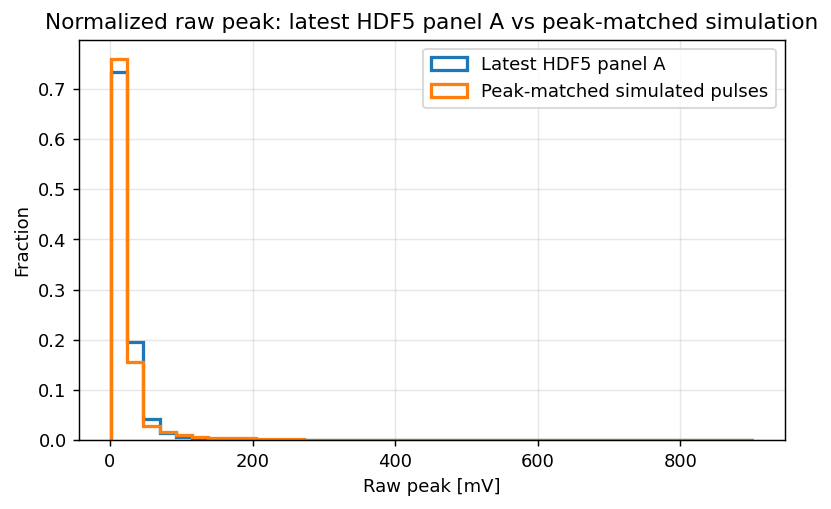

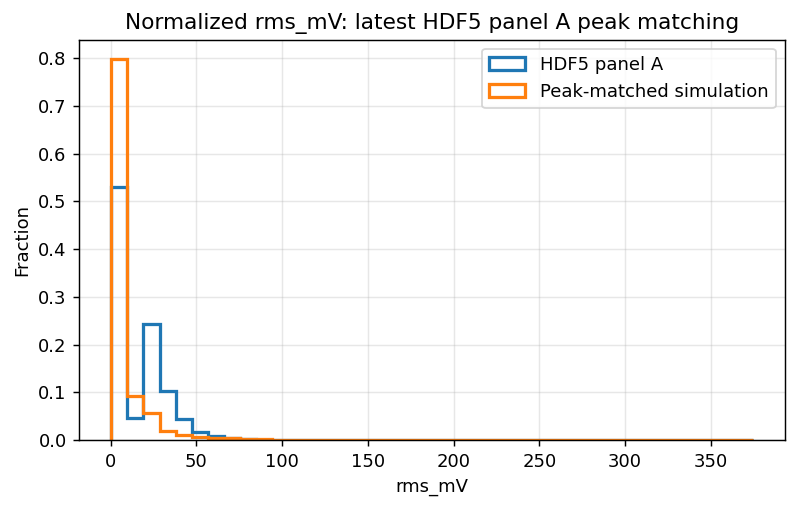

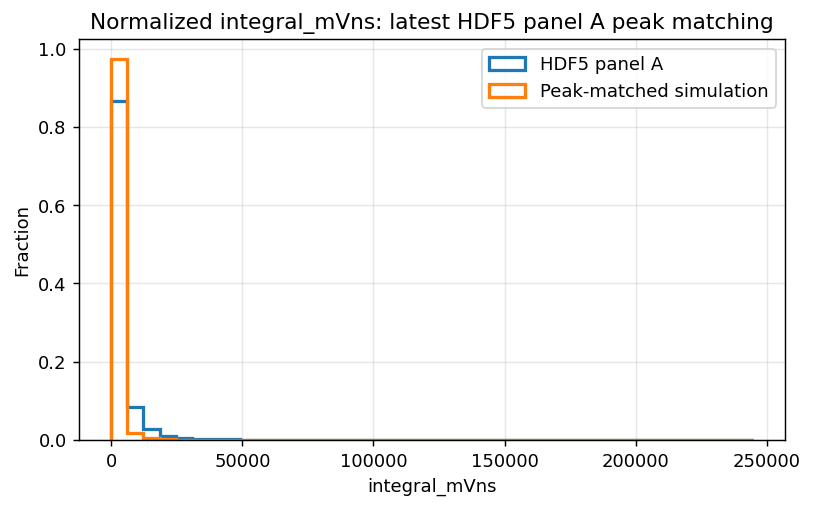

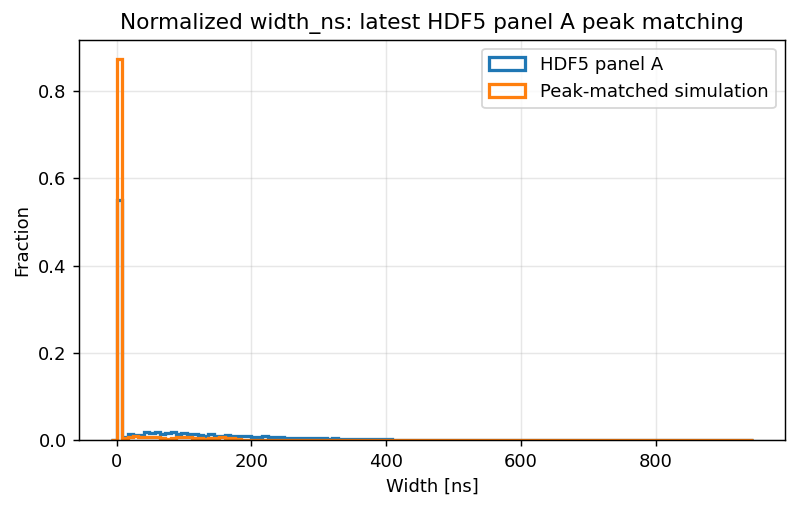

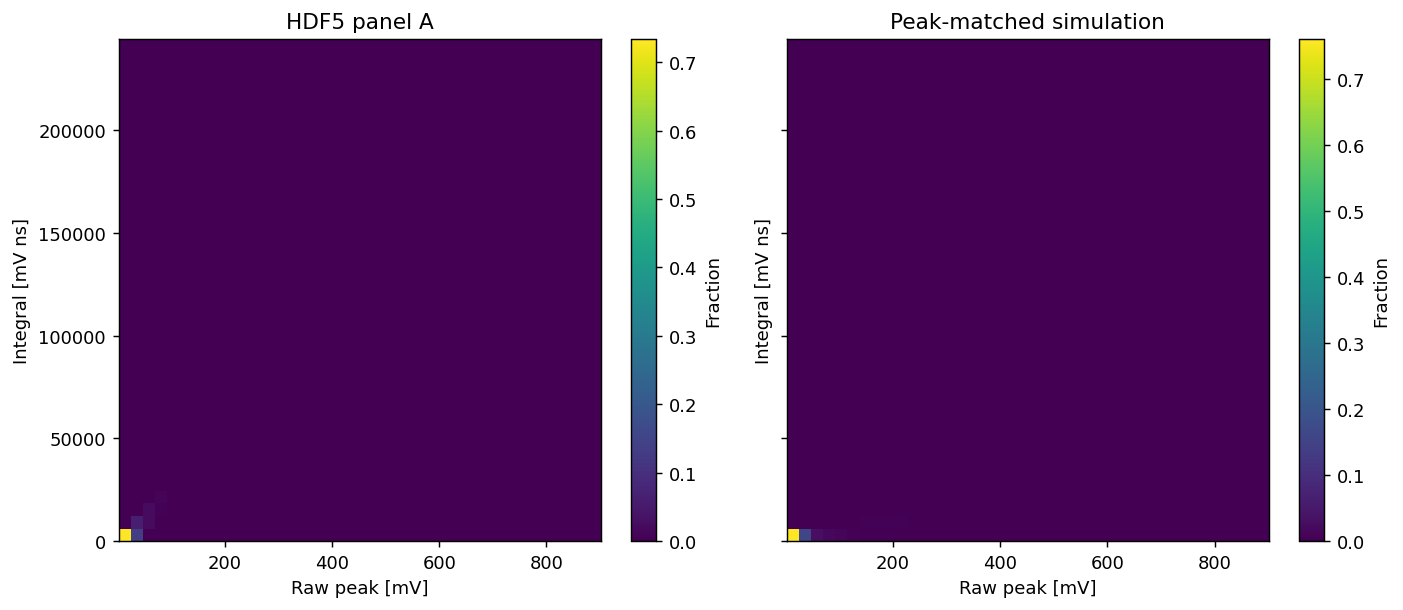

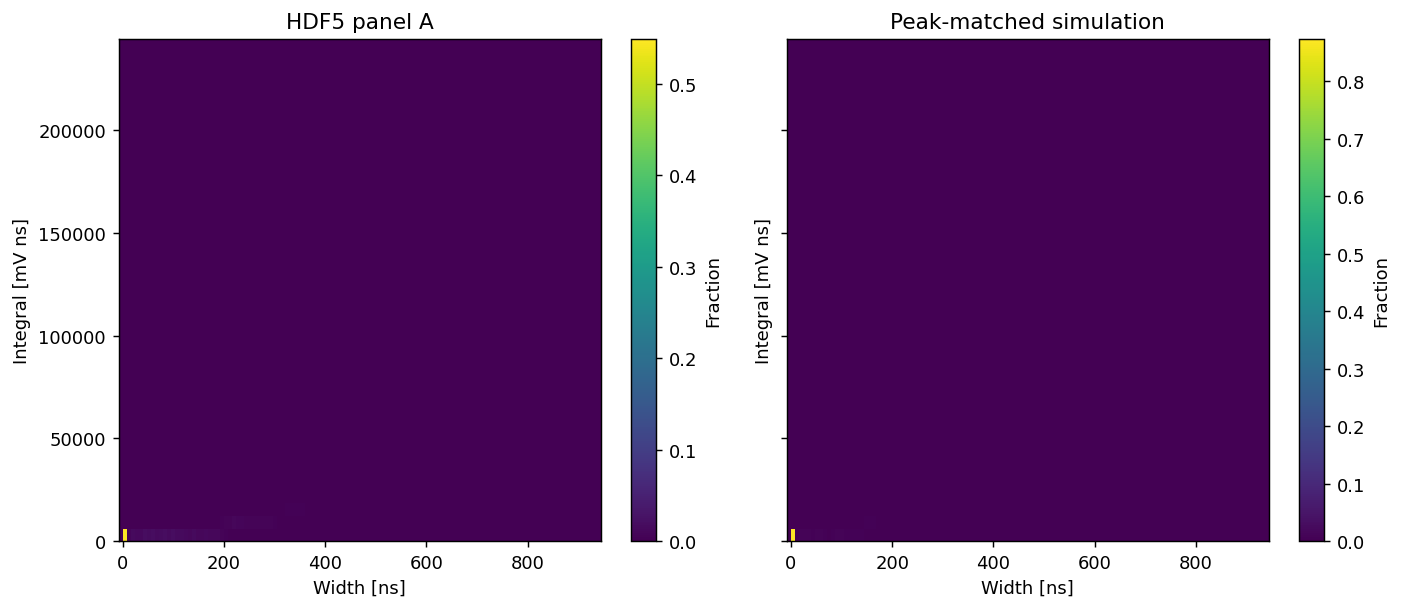

In [12]:
plot_normalized_hist_comparison(
    reference=matched_real["match_peak_mV"],
    candidate=matched_sim["match_peak_mV"],
    bins=common_linear_bins(matched_real["match_peak_mV"], matched_sim["match_peak_mV"], n_bins=40),
    xlabel="Raw peak [mV]",
    title=f"Normalized raw peak: latest HDF5 panel {PRIMARY_PANEL} vs peak-matched simulation",
    reference_label=f"Latest HDF5 panel {PRIMARY_PANEL}",
    candidate_label="Peak-matched simulated pulses",
    output_path=OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_hist_peak_normalized.png",
)

for feature in ["rms_mV", "integral_mVns", "width_ns"]:
    real_values = pd.to_numeric(matched_real[feature], errors="coerce")
    sim_values = pd.to_numeric(matched_sim[feature], errors="coerce")
    mask = np.isfinite(real_values) & np.isfinite(sim_values)
    if feature == "width_ns":
        bins = temporal_bins_8ns(real_values[mask], sim_values[mask])
        xlabel = "Width [ns]"
    else:
        bins = common_linear_bins(real_values[mask], sim_values[mask], n_bins=40)
        xlabel = feature
    plot_normalized_hist_comparison(
        reference=real_values[mask],
        candidate=sim_values[mask],
        bins=bins,
        xlabel=xlabel,
        title=f"Normalized {feature}: latest HDF5 panel {PRIMARY_PANEL} peak matching",
        reference_label=f"HDF5 panel {PRIMARY_PANEL}",
        candidate_label="Peak-matched simulation",
        output_path=OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_hist_{feature}_normalized.png",
    )

mask_integral = (
    np.isfinite(pd.to_numeric(matched_real["integral_mVns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim["integral_mVns"], errors="coerce"))
)
real_int_peak = matched_real[mask_integral].copy()
sim_int_peak = matched_sim[mask_integral].copy()
plot_side_by_side_hist2d_normalized(
    real_df=real_int_peak,
    sim_df=sim_int_peak,
    x_column="match_peak_mV",
    y_column="integral_mVns",
    x_label="Raw peak [mV]",
    y_label="Integral [mV ns]",
    title_left=f"HDF5 panel {PRIMARY_PANEL}",
    title_right="Peak-matched simulation",
    output_path=OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_hist2d_integral_vs_raw_peak_normalized.png",
    x_bins=common_linear_bins(real_int_peak["match_peak_mV"], sim_int_peak["match_peak_mV"], n_bins=40),
    y_bins=common_linear_bins(real_int_peak["integral_mVns"], sim_int_peak["integral_mVns"], n_bins=40),
)

mask_width_integral = (
    np.isfinite(pd.to_numeric(matched_real["width_ns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim["width_ns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_real["integral_mVns"], errors="coerce"))
    & np.isfinite(pd.to_numeric(matched_sim["integral_mVns"], errors="coerce"))
)
real_width_int = matched_real[mask_width_integral].copy()
sim_width_int = matched_sim[mask_width_integral].copy()
plot_side_by_side_hist2d_normalized(
    real_df=real_width_int,
    sim_df=sim_width_int,
    x_column="width_ns",
    y_column="integral_mVns",
    x_label="Width [ns]",
    y_label="Integral [mV ns]",
    title_left=f"HDF5 panel {PRIMARY_PANEL}",
    title_right="Peak-matched simulation",
    output_path=OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_hist2d_integral_vs_width_normalized.png",
    x_bins=temporal_bins_8ns(real_width_int["width_ns"], sim_width_int["width_ns"]),
    y_bins=common_linear_bins(real_width_int["integral_mVns"], sim_width_int["integral_mVns"], n_bins=40),
)


## 11. Waveform overlays


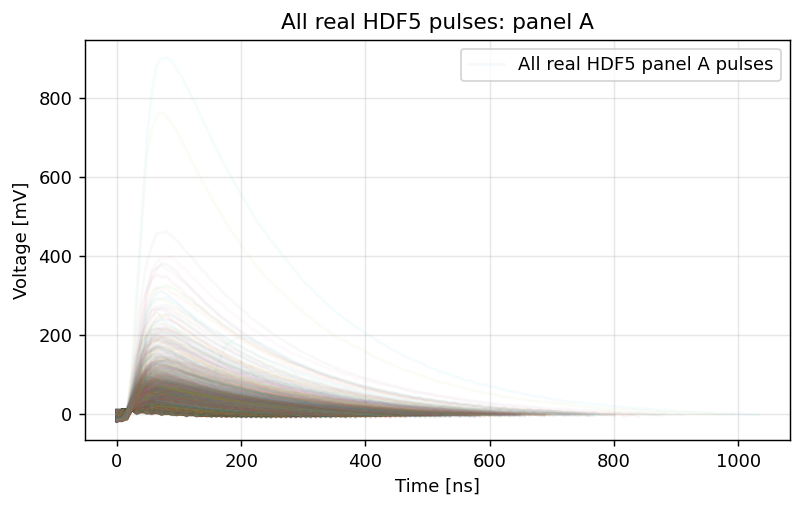

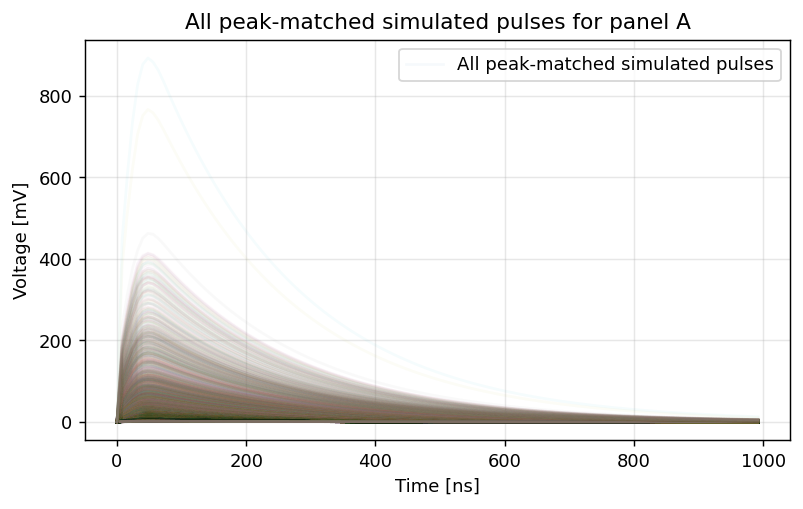

In [13]:
def reconstruct_simulated_waveform(row, config):
    rng = np.random.default_rng(int(row["simulation_seed"]))
    result = simulate_detector_event_from_config(
        generated_photons=int(row["generated_photons"]),
        config=config,
        rng=rng,
    )
    return result.sampled_time_ns, result.digitized_voltage_mV

sim_matched_waveforms = {
    str(row["event_id"]): reconstruct_simulated_waveform(row, matched_config)
    for _, row in matched_sim.iterrows()
}

all_real_waveforms = [real_waveforms[event_id] for event_id in matched_real["event_id"] if event_id in real_waveforms]
all_sim_waveforms = [sim_matched_waveforms[event_id] for event_id in matched_sim["event_id"] if event_id in sim_matched_waveforms]

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(all_real_waveforms, xlabel="Time [ns]", ylabel="Voltage [mV]", label=f"All real HDF5 panel {PRIMARY_PANEL} pulses", alpha=0.04, ax=ax)
ax.set_title(f"All real HDF5 pulses: panel {PRIMARY_PANEL}")
save_figure(fig, OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_overlay_all_real_pulses.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(all_sim_waveforms, xlabel="Time [ns]", ylabel="Voltage [mV]", label="All peak-matched simulated pulses", alpha=0.04, ax=ax)
ax.set_title(f"All peak-matched simulated pulses for panel {PRIMARY_PANEL}")
save_figure(fig, OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_overlay_all_matched_simulated_pulses.png")
plt.show()


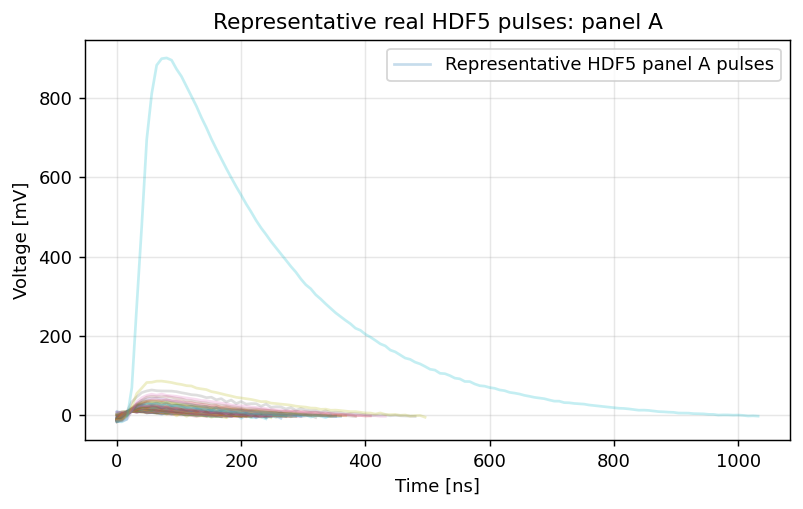

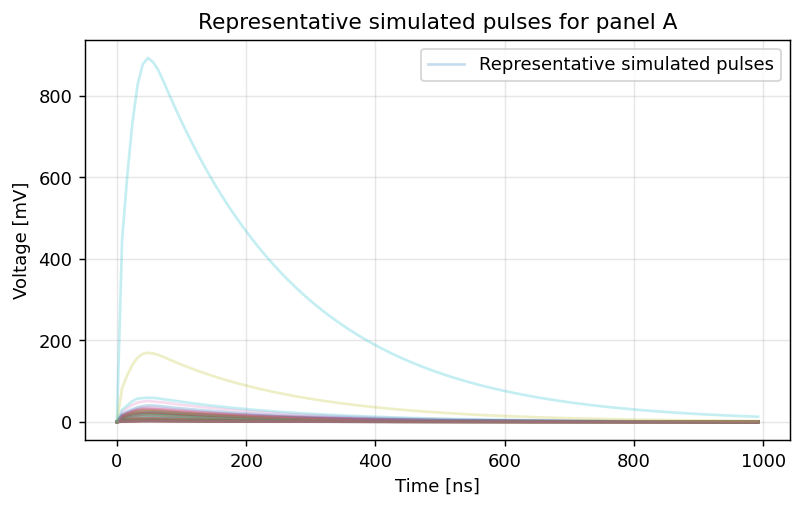

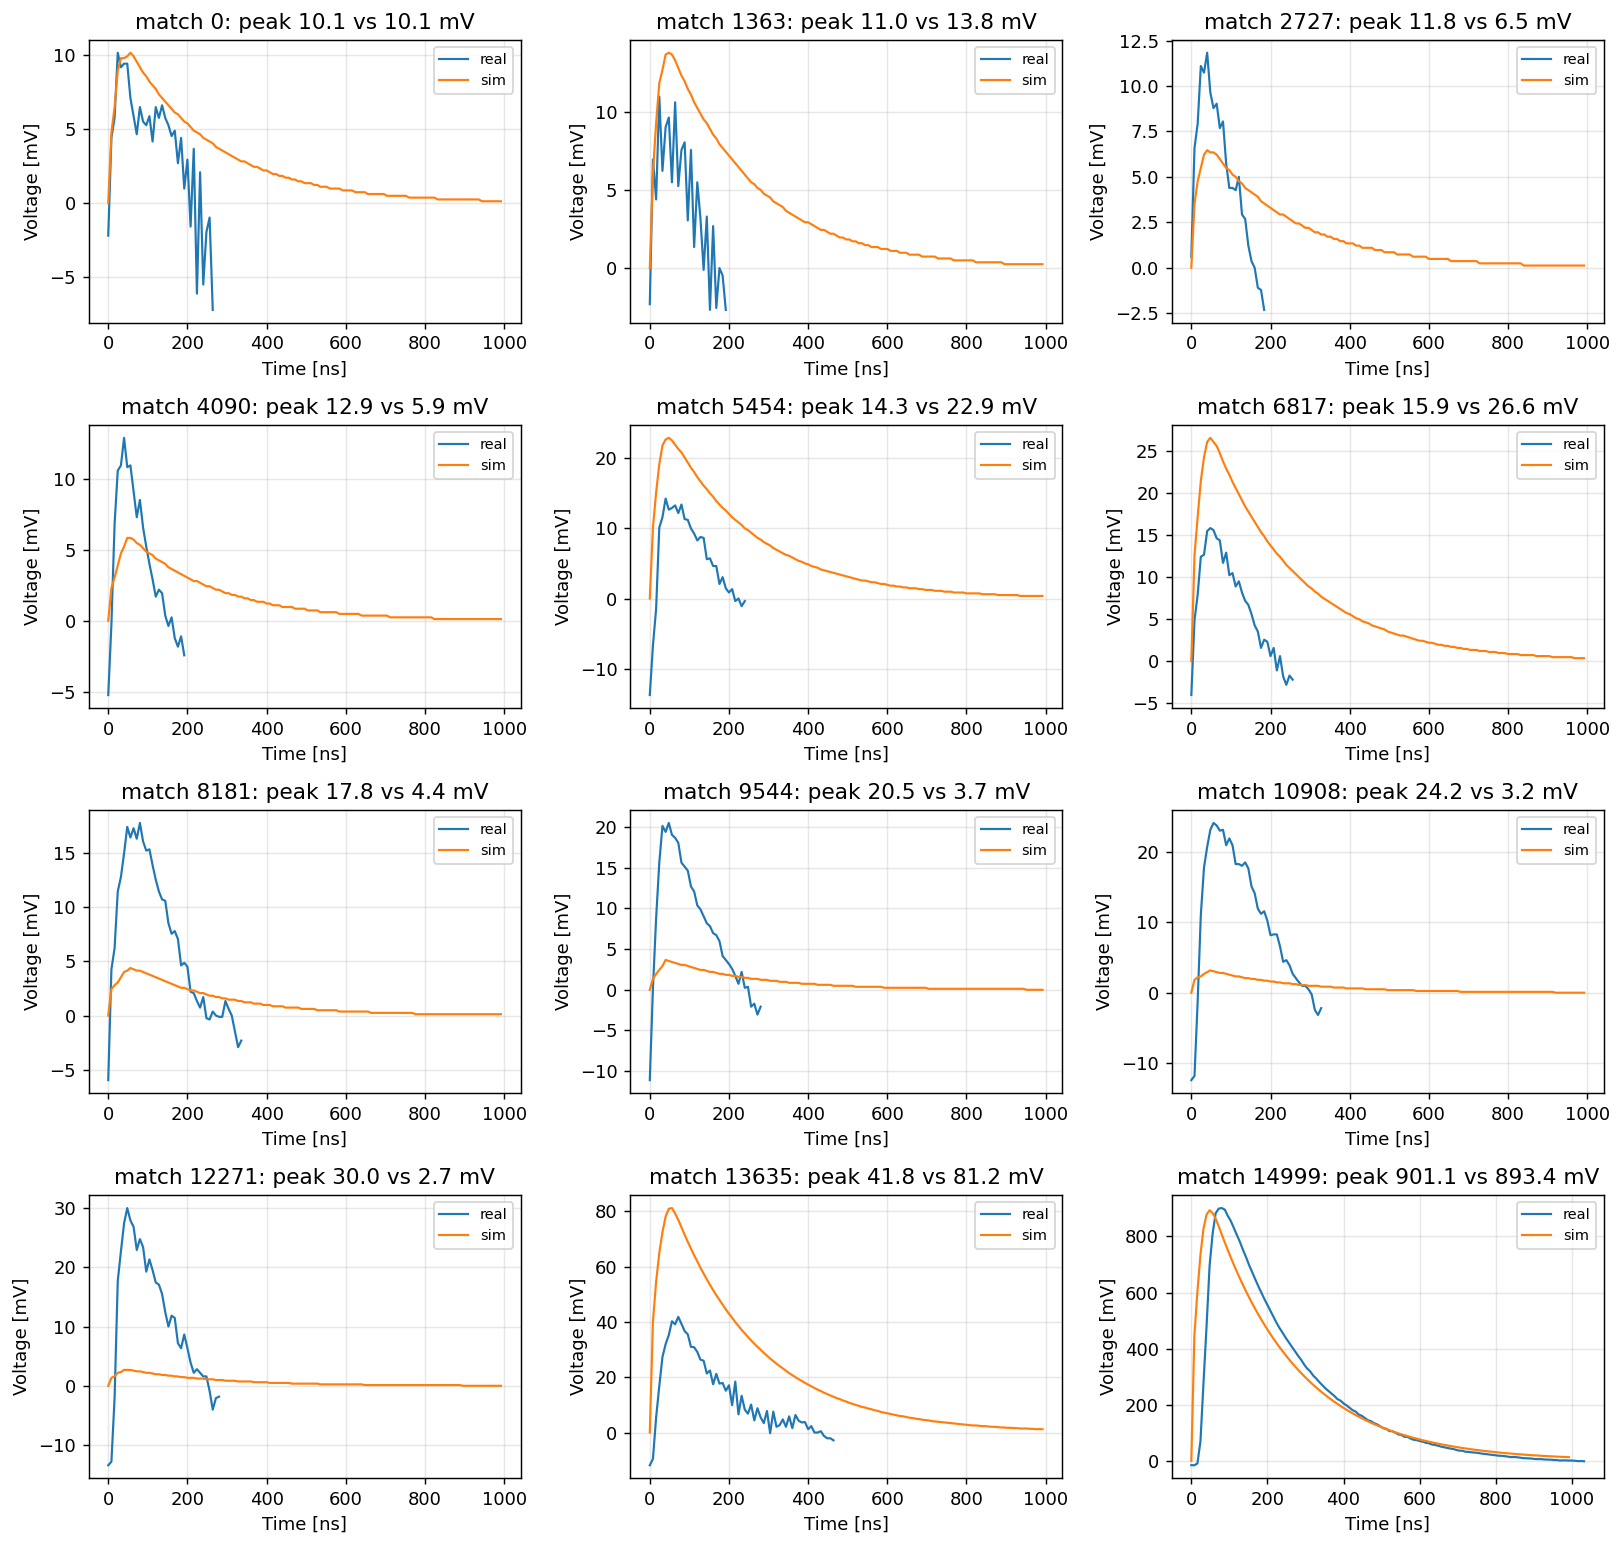

In [14]:
pair_order = peak_match_table.sort_values("real_match_peak_mV").reset_index(drop=True)
representative_positions = np.linspace(0, len(pair_order) - 1, min(N_REPRESENTATIVE_OVERLAY, len(pair_order))).astype(int)
representative_match_ids = pair_order.iloc[representative_positions]["match_id"].astype(int).tolist()

rep_real = matched_real[matched_real["match_id"].isin(representative_match_ids)].copy().sort_values("match_peak_mV")
rep_sim = matched_sim.set_index("match_id").loc[rep_real["match_id"]].reset_index()
rep_real_waveforms = [real_waveforms[event_id] for event_id in rep_real["event_id"] if event_id in real_waveforms]
rep_sim_waveforms = [sim_matched_waveforms[event_id] for event_id in rep_sim["event_id"] if event_id in sim_matched_waveforms]

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(rep_real_waveforms, xlabel="Time [ns]", ylabel="Voltage [mV]", label=f"Representative HDF5 panel {PRIMARY_PANEL} pulses", alpha=0.25, ax=ax)
ax.set_title(f"Representative real HDF5 pulses: panel {PRIMARY_PANEL}")
save_figure(fig, OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_overlay_representative_real_pulses.png")
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
plot_waveform_overlay(rep_sim_waveforms, xlabel="Time [ns]", ylabel="Voltage [mV]", label="Representative simulated pulses", alpha=0.25, ax=ax)
ax.set_title(f"Representative simulated pulses for panel {PRIMARY_PANEL}")
save_figure(fig, OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_overlay_representative_simulated_pulses.png")
plt.show()

pair_positions = np.linspace(0, len(pair_order) - 1, min(N_REPRESENTATIVE_PAIR_PLOTS, len(pair_order))).astype(int)
pair_ids = pair_order.iloc[pair_positions]["match_id"].astype(int).tolist()
n_cols = 3
n_rows = int(np.ceil(len(pair_ids) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.0 * n_rows), squeeze=False)
for ax, match_id in zip(axes.ravel(), pair_ids):
    real_row = matched_real.loc[matched_real["match_id"] == match_id].iloc[0]
    sim_row = matched_sim.loc[matched_sim["match_id"] == match_id].iloc[0]
    real_waveform = real_waveforms[str(real_row["event_id"])]
    sim_waveform = sim_matched_waveforms[str(sim_row["event_id"])]
    ax.plot(real_waveform[0], real_waveform[1], label="real", linewidth=1.2)
    ax.plot(sim_waveform[0], sim_waveform[1], label="sim", linewidth=1.2)
    ax.set_title(f"match {match_id}: peak {real_row['match_peak_mV']:.1f} vs {sim_row['match_peak_mV']:.1f} mV")
    ax.set_xlabel("Time [ns]")
    ax.set_ylabel("Voltage [mV]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(pair_ids):]:
    ax.axis("off")
fig.tight_layout()
save_figure(fig, OUTPUT_FIGURES / f"latest_h5_panel_{PRIMARY_PANEL}_overlay_representative_real_sim_pairs.png")
plt.show()


## 12. Quantitative summary


In [15]:
comparison = compare_real_sim_features(
    matched_real,
    matched_sim,
    feature_columns=["match_peak_mV", "rms_mV", "integral_mVns", "width_ns"],
    relationships=[("match_peak_mV", "integral_mVns"), ("width_ns", "integral_mVns")],
)
comparison.distribution_comparison.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_feature_distribution_comparison.csv", index=False)
comparison.correlation_comparison.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_feature_correlation_comparison.csv", index=False)
comparison.validity_summary.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_feature_validity_summary.csv", index=False)
display(comparison.distribution_comparison)
display(comparison.correlation_comparison)
display(comparison.validity_summary)

summary = pd.DataFrame(
    {
        "metric": [
            "primary_panel",
            "segmentation_method",
            "representative_real_pulse_target",
            "n_representative_real_hdf5_pulses_used",
            "n_simulated_pool_events",
            "n_matched_pairs",
            "estimated_sampling_interval_ns",
            "temporal_bin_ns",
            "mean_abs_delta_raw_peak_mV",
            "median_abs_delta_raw_peak_mV",
            "max_abs_delta_raw_peak_mV",
            "eta_transport",
            "tau_f_ns",
            "arrival_spread_ns",
            "fixed_voltage_scale_mV_per_pe",
            "fixed_pde",
            "exploratory_all_corsika_detectors",
        ],
        "value": [
            PRIMARY_PANEL,
            SEGMENTATION_METHOD,
            REPRESENTATIVE_REAL_PULSES,
            len(real_match),
            len(sim_pool_features),
            len(peak_match_table),
            real_sampling_interval_ns,
            TEMPORAL_BIN_NS,
            peak_match_table["abs_delta_peak_mV"].mean(),
            peak_match_table["abs_delta_peak_mV"].median(),
            peak_match_table["abs_delta_peak_mV"].max(),
            ETA_TRANSPORT,
            TAU_F_NS,
            ARRIVAL_SPREAD_NS,
            matched_config["voltage_conversion"]["voltage_scale_mV_per_pe"],
            matched_config["photon_transport"]["pde"],
            True,
        ],
    }
)
display(summary)
summary.to_csv(OUTPUT_TABLES / f"latest_h5_panel_{PRIMARY_PANEL}_analysis_summary.csv", index=False)
print("Output tables:", OUTPUT_TABLES)
print("Output figures:", OUTPUT_FIGURES)


,feature,n_reference,n_candidate,mean_reference,mean_candidate,median_reference,median_candidate,std_reference,std_candidate,iqr_reference,...,mean_relative_difference,median_relative_difference,std_ratio,iqr_ratio,range_coverage,delta_p05,delta_p25,delta_p50,delta_p75,delta_p95
0,match_peak_mV,6763,1893,34.952738,90.824697,26.840000,61.523438,30.653146,75.962544,16.470000,...,1.598500,1.292229,2.478132,3.831837,0.967937,19.418813,21.374539,34.683437,68.014891,174.543591
1,rms_mV,6763,1893,30.422917,35.054836,26.322301,25.935752,15.044809,23.022020,12.213503,...,0.152251,-0.014685,1.530230,1.549006,0.724926,-0.507006,-1.319477,-0.386548,5.385814,29.452048
2,integral_mVns,6763,1893,5862.273208,3737.187325,3325.232000,2164.062500,8668.404299,4364.213828,5746.932000,...,-0.362502,-0.349200,0.503462,0.712931,0.185798,-139.445238,-640.757531,-1161.169500,-2290.521563,-5940.413138
3,width_ns,6763,1893,156.440633,84.120444,128.000000,80.000000,116.816947,49.596024,152.000000,...,-0.462285,-0.375000,0.424562,0.578947,0.189655,-8.000000,-24.000000,-48.000000,-88.000000,-216.000000


,relationship,x_column,y_column,n_reference,n_candidate,pearson_reference,pearson_candidate,pearson_delta,spearman_reference,spearman_candidate,spearman_delta,linear_slope_reference,linear_slope_candidate,linear_slope_relative_difference,linear_r2_reference,linear_r2_candidate,linear_r2_delta,quadratic_r2_reference,quadratic_r2_candidate,quadratic_r2_delta
0,integral_mVns_vs_match_peak_mV,match_peak_mV,integral_mVns,6763,1893,0.983754,0.995284,0.011531,0.892831,0.986880,0.094048,278.195743,57.181256,-0.794457,0.967771,0.990591,0.022820,0.968524,0.992621,0.024098
1,integral_mVns_vs_width_ns,width_ns,integral_mVns,6763,1893,0.853088,0.849859,-0.003229,0.997428,0.998142,0.000714,63.303380,74.783499,0.181351,0.727758,0.722259,-0.005499,0.932018,0.888533,-0.043484


,dataset,extraction_status,valid,count,total_events,valid_events,invalid_events,valid_fraction
0,real,ok,False,8237,15000,6763,8237,0.450867
1,real,ok,True,6763,15000,6763,8237,0.450867
2,simulated,ok,False,13107,15000,1893,13107,0.126200
3,simulated,ok,True,1893,15000,1893,13107,0.126200


,metric,value
0,primary_panel,A
1,segmentation_method,gap
2,representative_real_pulse_target,15000
3,n_representative_real_hdf5_pulses_used,15000
4,n_simulated_pool_events,20000
5,n_matched_pairs,15000
6,estimated_sampling_interval_ns,8.0
7,temporal_bin_ns,8.0
8,mean_abs_delta_raw_peak_mV,17.706266
9,median_abs_delta_raw_peak_mV,11.972594


Output tables: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables
Output figures: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\figures


Final diagnostic cell
Panel: A
Zoom percentile range: 0.5 to 99.5
Temporal bin width for width_ns plots: 8.0 ns
Full-range plots above remain valid as diagnostics. This cell adds zoomed central-population plots.

Feature percentile summary:


,source,feature,n_finite,p0,p1,p5,p50,p95,p99,p99_5,p100
0,hdf5_panel_A,match_peak_mV,15000,10.126000,10.126000,10.492000,16.836000,54.412000,110.532000,145.668610,901.092000
1,hdf5_panel_A,integral_mVns,15000,0.000000,0.000000,0.000000,0.000000,12308.872800,27662.118960,37806.245720,244636.840000
2,hdf5_panel_A,width_ns,15000,0.000000,0.000000,0.000000,0.000000,304.000000,456.000000,520.000000,936.000000
3,hdf5_panel_A,rms_mV,15000,2.926729,3.949840,4.433502,9.024955,43.299302,69.581934,85.053578,374.303657
4,peak_matched_simulation,match_peak_mV,15000,2.075195,2.075195,2.319336,10.620117,73.248291,211.676025,271.366577,893.432617
5,peak_matched_simulation,integral_mVns,15000,0.000000,0.000000,0.000000,0.000000,2933.300781,10772.495117,14054.814453,45571.289062
6,peak_matched_simulation,width_ns,15000,0.000000,0.000000,0.000000,0.000000,96.000000,160.000000,168.000000,184.000000
7,peak_matched_simulation,rms_mV,15000,0.530859,0.657459,0.812948,3.896717,29.985262,71.311834,89.762247,276.380637


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_feature_percentiles.csv


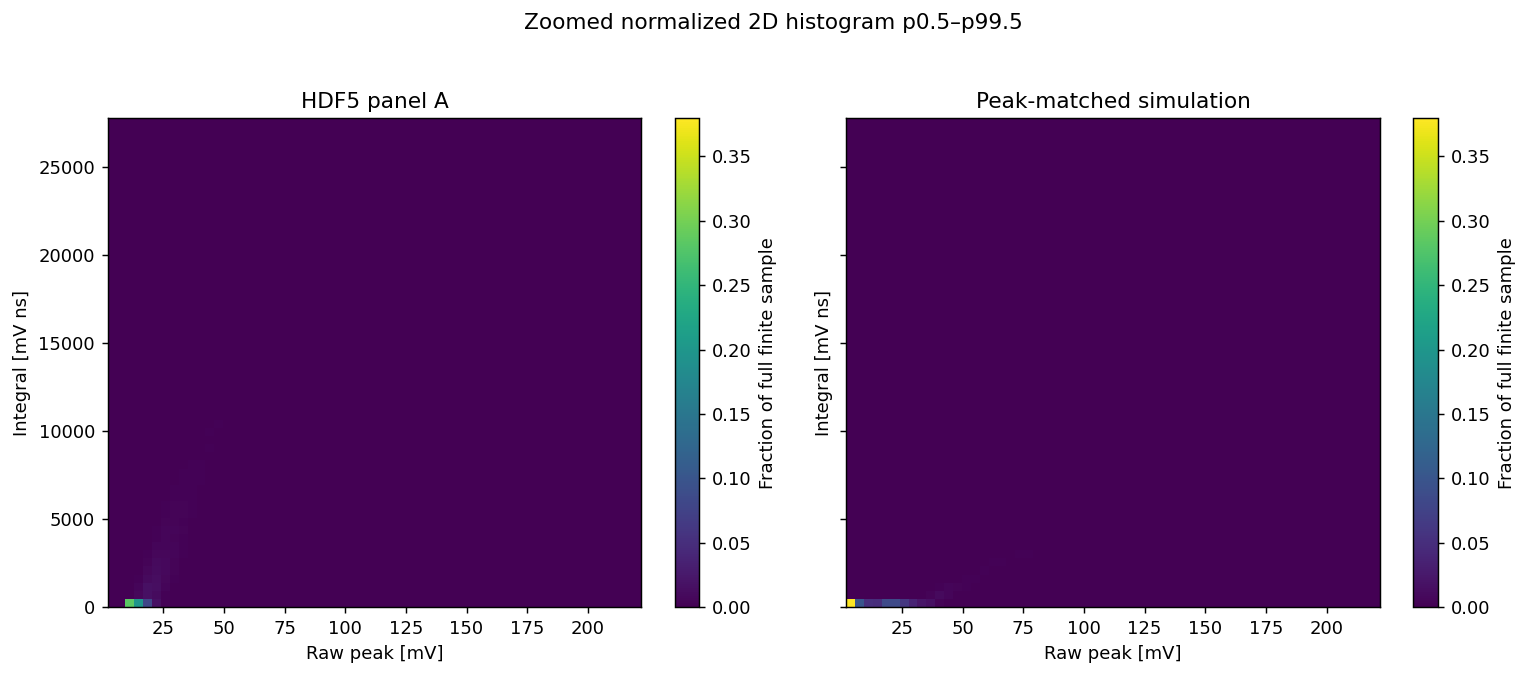


Width bin check:
First width edge: 0.0
Last width edge: 456.0
Unique width bin spacings: [8.]


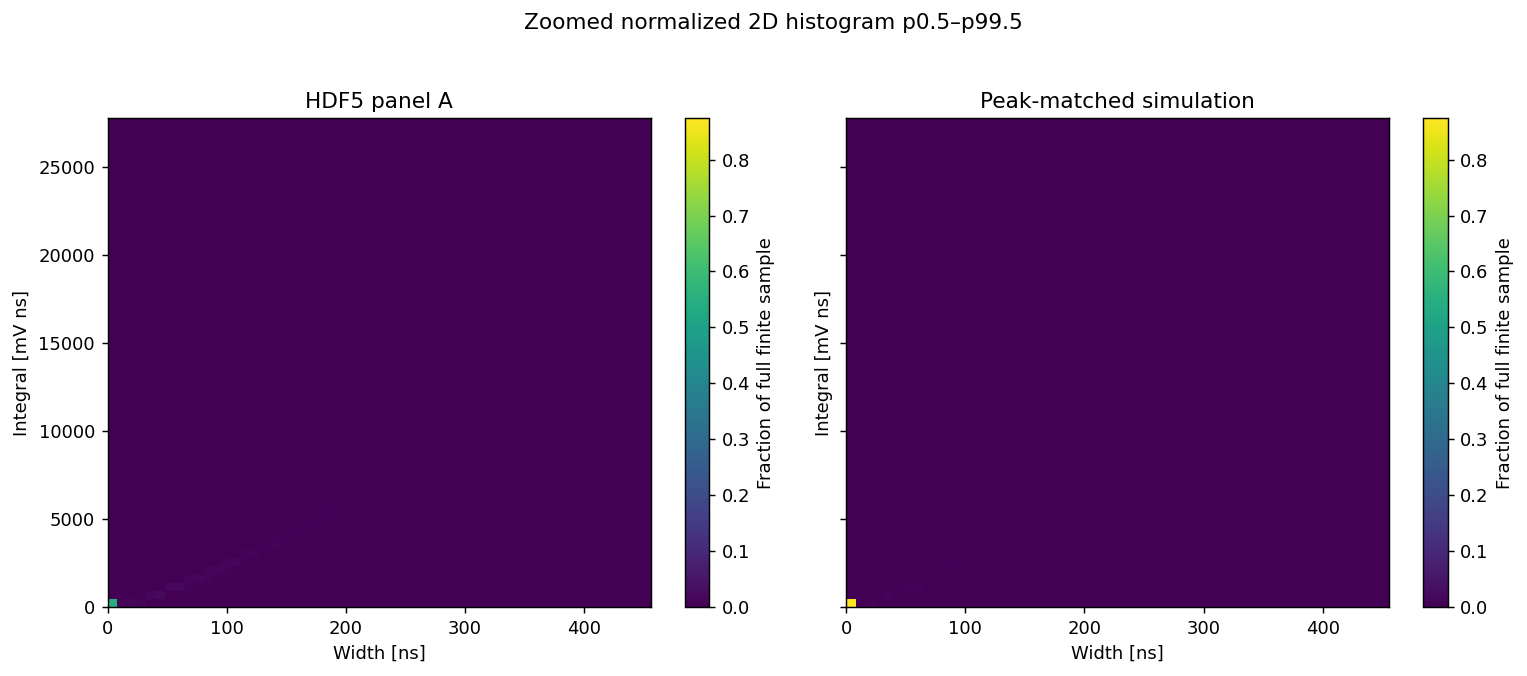


Zoom exclusion report:


,plot,source,x_column,y_column,finite_events,inside_zoom,outside_zoom,outside_zoom_fraction,x_min,x_max,y_min,y_max
0,latest_h5_panel_A_hist2d_integral_vs_raw_peak_...,real_h5,match_peak_mV,integral_mVns,15000,14852,148,0.009867,2.075195,222.049561,0.0,27736.097321
1,latest_h5_panel_A_hist2d_integral_vs_raw_peak_...,matched_simulation,match_peak_mV,integral_mVns,15000,14873,127,0.008467,2.075195,222.049561,0.0,27736.097321
2,latest_h5_panel_A_hist2d_integral_vs_width_zoo...,real_h5,width_ns,integral_mVns,15000,14840,160,0.010667,0.000000,456.000000,0.0,27736.097321
3,latest_h5_panel_A_hist2d_integral_vs_width_zoo...,matched_simulation,width_ns,integral_mVns,15000,14998,2,0.000133,0.000000,456.000000,0.0,27736.097321


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_zoom_exclusion_report.csv

Diagnostic notes:

# HDF5 panel A zoomed 2D diagnostic

Full-range 2D plots are kept as diagnostic figures because they show the complete dynamic range and possible outliers.

The zoomed 2D plots use the central p0.5–p99.5 range computed from the combined real HDF5 and matched simulation samples. This zoom is only for visualization; outliers are not removed from quantitative tables.

The width_ns axis uses fixed 8.0 ns bins, consistent with the Red Pitaya FPGA timing resolution.

Generated files:
- latest_h5_panel_A_feature_percentiles.csv
- latest_h5_panel_A_hist2d_integral_vs_raw_peak_zoom_p995_normalized.png
- latest_h5_panel_A_hist2d_integral_vs_width_zoom_p995_normalized.png
- latest_h5_panel_A_zoom_exclusion_report.csv

Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_zoo

In [16]:
# ============================================================
# FINAL CELL — Percentile diagnostics + zoomed normalized 2D plots
# ============================================================
#
# Purpose:
# - Keep full-range plots as diagnostics.
# - Add percentile tables to show whether outliers are stretching the axes.
# - Add zoomed 2D histograms using central percentile ranges.
# - Preserve 8 ns binning for any width_ns axis.
# - Do NOT remove outliers from quantitative tables.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

# ----------------------------
# Configuration
# ----------------------------

ZOOM_PERCENTILE_LOW = 0.5
ZOOM_PERCENTILE_HIGH = 99.5

TEMPORAL_BIN_NS = 8.0  # Red Pitaya FPGA timing resolution

PANEL_LABEL = str(PRIMARY_PANEL)

OUTPUT_TABLES = Path(OUTPUT_TABLES)
OUTPUT_FIGURES = Path(OUTPUT_FIGURES)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

FEATURES_FOR_PERCENTILES = [
    "match_peak_mV",
    "integral_mVns",
    "width_ns",
    "rms_mV",
]

print("Final diagnostic cell")
print("Panel:", PANEL_LABEL)
print("Zoom percentile range:", ZOOM_PERCENTILE_LOW, "to", ZOOM_PERCENTILE_HIGH)
print("Temporal bin width for width_ns plots:", TEMPORAL_BIN_NS, "ns")
print("Full-range plots above remain valid as diagnostics. This cell adds zoomed central-population plots.")


# ----------------------------
# Helper functions
# ----------------------------

def finite_array(values):
    arr = pd.to_numeric(values, errors="coerce").to_numpy(dtype=float)
    return arr[np.isfinite(arr)]


def feature_percentile_rows(df, source_label, features):
    rows = []

    for feature in features:
        if feature not in df.columns:
            rows.append(
                {
                    "source": source_label,
                    "feature": feature,
                    "n_finite": 0,
                    "p0": np.nan,
                    "p1": np.nan,
                    "p5": np.nan,
                    "p50": np.nan,
                    "p95": np.nan,
                    "p99": np.nan,
                    "p99_5": np.nan,
                    "p100": np.nan,
                }
            )
            continue

        values = finite_array(df[feature])

        if len(values) == 0:
            rows.append(
                {
                    "source": source_label,
                    "feature": feature,
                    "n_finite": 0,
                    "p0": np.nan,
                    "p1": np.nan,
                    "p5": np.nan,
                    "p50": np.nan,
                    "p95": np.nan,
                    "p99": np.nan,
                    "p99_5": np.nan,
                    "p100": np.nan,
                }
            )
            continue

        p = np.percentile(values, [0, 1, 5, 50, 95, 99, 99.5, 100])

        rows.append(
            {
                "source": source_label,
                "feature": feature,
                "n_finite": len(values),
                "p0": p[0],
                "p1": p[1],
                "p5": p[2],
                "p50": p[3],
                "p95": p[4],
                "p99": p[5],
                "p99_5": p[6],
                "p100": p[7],
            }
        )

    return rows


def shared_percentile_limits(real_df, sim_df, column, low=0.5, high=99.5):
    real_values = finite_array(real_df[column])
    sim_values = finite_array(sim_df[column])

    combined = np.concatenate([real_values, sim_values])
    combined = combined[np.isfinite(combined)]

    if len(combined) == 0:
        raise ValueError(f"No finite values available for {column}")

    lower, upper = np.percentile(combined, [low, high])

    if lower == upper:
        lower -= 0.5
        upper += 0.5

    return float(lower), float(upper)


def linear_edges_from_limits(lower, upper, n_bins=50):
    if lower == upper:
        lower -= 0.5
        upper += 0.5

    return np.linspace(lower, upper, n_bins + 1)


def width_edges_8ns_from_limits(lower, upper, bin_width_ns=8.0):
    lower_edge = bin_width_ns * np.floor(lower / bin_width_ns)
    upper_edge = bin_width_ns * np.ceil(upper / bin_width_ns)

    lower_edge = max(0.0, lower_edge)

    if upper_edge <= lower_edge:
        upper_edge = lower_edge + bin_width_ns

    return np.arange(lower_edge, upper_edge + bin_width_ns, bin_width_ns)


def zoom_mask(df, x_column, y_column, x_limits, y_limits):
    x = pd.to_numeric(df[x_column], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_column], errors="coerce").to_numpy(dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)

    inside = (
        finite
        & (x >= x_limits[0])
        & (x <= x_limits[1])
        & (y >= y_limits[0])
        & (y <= y_limits[1])
    )

    return finite, inside


def normalized_hist2d_counts(df, x_column, y_column, x_edges, y_edges, full_finite_count):
    x = pd.to_numeric(df[x_column], errors="coerce").to_numpy(dtype=float)
    y = pd.to_numeric(df[y_column], errors="coerce").to_numpy(dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    inside = (
        (x >= x_edges[0])
        & (x <= x_edges[-1])
        & (y >= y_edges[0])
        & (y <= y_edges[-1])
    )

    x = x[inside]
    y = y[inside]

    if full_finite_count <= 0:
        weights = None
    else:
        weights = np.ones(len(x), dtype=float) / full_finite_count

    hist, _, _ = np.histogram2d(
        x,
        y,
        bins=[x_edges, y_edges],
        weights=weights,
    )

    return hist


def plot_zoomed_normalized_hist2d_pair(
    real_df,
    sim_df,
    x_column,
    y_column,
    x_edges,
    y_edges,
    x_label,
    y_label,
    title_left,
    title_right,
    output_path,
):
    real_finite, real_inside = zoom_mask(
        real_df,
        x_column=x_column,
        y_column=y_column,
        x_limits=(x_edges[0], x_edges[-1]),
        y_limits=(y_edges[0], y_edges[-1]),
    )
    sim_finite, sim_inside = zoom_mask(
        sim_df,
        x_column=x_column,
        y_column=y_column,
        x_limits=(x_edges[0], x_edges[-1]),
        y_limits=(y_edges[0], y_edges[-1]),
    )

    real_full_n = int(real_finite.sum())
    sim_full_n = int(sim_finite.sum())

    real_hist = normalized_hist2d_counts(
        real_df,
        x_column=x_column,
        y_column=y_column,
        x_edges=x_edges,
        y_edges=y_edges,
        full_finite_count=real_full_n,
    )
    sim_hist = normalized_hist2d_counts(
        sim_df,
        x_column=x_column,
        y_column=y_column,
        x_edges=x_edges,
        y_edges=y_edges,
        full_finite_count=sim_full_n,
    )

    vmax = max(float(np.nanmax(real_hist)), float(np.nanmax(sim_hist)))
    if vmax <= 0:
        vmax = None

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    mesh_real = axes[0].pcolormesh(
        x_edges,
        y_edges,
        real_hist.T,
        shading="auto",
        vmin=0,
        vmax=vmax,
    )
    axes[0].set_title(title_left)
    axes[0].set_xlabel(x_label)
    axes[0].set_ylabel(y_label)
    fig.colorbar(mesh_real, ax=axes[0], label="Fraction of full finite sample")

    mesh_sim = axes[1].pcolormesh(
        x_edges,
        y_edges,
        sim_hist.T,
        shading="auto",
        vmin=0,
        vmax=vmax,
    )
    axes[1].set_title(title_right)
    axes[1].set_xlabel(x_label)
    axes[1].set_ylabel(y_label)
    fig.colorbar(mesh_sim, ax=axes[1], label="Fraction of full finite sample")

    fig.suptitle(
        f"Zoomed normalized 2D histogram "
        f"p{ZOOM_PERCENTILE_LOW}–p{ZOOM_PERCENTILE_HIGH}",
        y=1.03,
    )

    fig.tight_layout()
    save_figure(fig, output_path)
    plt.show()

    report_rows = [
        {
            "plot": output_path.stem,
            "source": "real_h5",
            "x_column": x_column,
            "y_column": y_column,
            "finite_events": real_full_n,
            "inside_zoom": int(real_inside.sum()),
            "outside_zoom": int(real_full_n - real_inside.sum()),
            "outside_zoom_fraction": (
                float((real_full_n - real_inside.sum()) / real_full_n)
                if real_full_n > 0
                else np.nan
            ),
            "x_min": float(x_edges[0]),
            "x_max": float(x_edges[-1]),
            "y_min": float(y_edges[0]),
            "y_max": float(y_edges[-1]),
        },
        {
            "plot": output_path.stem,
            "source": "matched_simulation",
            "x_column": x_column,
            "y_column": y_column,
            "finite_events": sim_full_n,
            "inside_zoom": int(sim_inside.sum()),
            "outside_zoom": int(sim_full_n - sim_inside.sum()),
            "outside_zoom_fraction": (
                float((sim_full_n - sim_inside.sum()) / sim_full_n)
                if sim_full_n > 0
                else np.nan
            ),
            "x_min": float(x_edges[0]),
            "x_max": float(x_edges[-1]),
            "y_min": float(y_edges[0]),
            "y_max": float(y_edges[-1]),
        },
    ]

    return report_rows


# ----------------------------
# 1. Percentile summary table
# ----------------------------

percentile_rows = []
percentile_rows.extend(
    feature_percentile_rows(
        matched_real,
        source_label=f"hdf5_panel_{PANEL_LABEL}",
        features=FEATURES_FOR_PERCENTILES,
    )
)
percentile_rows.extend(
    feature_percentile_rows(
        matched_sim,
        source_label="peak_matched_simulation",
        features=FEATURES_FOR_PERCENTILES,
    )
)

percentile_table = pd.DataFrame(percentile_rows)

percentile_output = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_feature_percentiles.csv"
)

percentile_table.to_csv(percentile_output, index=False)

print("\nFeature percentile summary:")
display(percentile_table)

print("Saved:", percentile_output)


# ----------------------------
# 2. Zoomed normalized 2D: integral vs raw peak
# ----------------------------

peak_limits = shared_percentile_limits(
    matched_real,
    matched_sim,
    column="match_peak_mV",
    low=ZOOM_PERCENTILE_LOW,
    high=ZOOM_PERCENTILE_HIGH,
)

integral_limits_peak = shared_percentile_limits(
    matched_real,
    matched_sim,
    column="integral_mVns",
    low=ZOOM_PERCENTILE_LOW,
    high=ZOOM_PERCENTILE_HIGH,
)

peak_edges = linear_edges_from_limits(
    peak_limits[0],
    peak_limits[1],
    n_bins=60,
)

integral_edges_peak = linear_edges_from_limits(
    integral_limits_peak[0],
    integral_limits_peak[1],
    n_bins=60,
)

zoom_report_rows = []

zoom_report_rows.extend(
    plot_zoomed_normalized_hist2d_pair(
        real_df=matched_real,
        sim_df=matched_sim,
        x_column="match_peak_mV",
        y_column="integral_mVns",
        x_edges=peak_edges,
        y_edges=integral_edges_peak,
        x_label="Raw peak [mV]",
        y_label="Integral [mV ns]",
        title_left=f"HDF5 panel {PANEL_LABEL}",
        title_right="Peak-matched simulation",
        output_path=(
            OUTPUT_FIGURES
            / f"latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_raw_peak_zoom_p995_normalized.png"
        ),
    )
)


# ----------------------------
# 3. Zoomed normalized 2D: integral vs width
# ----------------------------
# IMPORTANT:
# width_ns bin edges are forced to 8 ns, even in zoomed plots.

width_limits = shared_percentile_limits(
    matched_real,
    matched_sim,
    column="width_ns",
    low=ZOOM_PERCENTILE_LOW,
    high=ZOOM_PERCENTILE_HIGH,
)

integral_limits_width = shared_percentile_limits(
    matched_real,
    matched_sim,
    column="integral_mVns",
    low=ZOOM_PERCENTILE_LOW,
    high=ZOOM_PERCENTILE_HIGH,
)

width_edges = width_edges_8ns_from_limits(
    width_limits[0],
    width_limits[1],
    bin_width_ns=TEMPORAL_BIN_NS,
)

integral_edges_width = linear_edges_from_limits(
    integral_limits_width[0],
    integral_limits_width[1],
    n_bins=60,
)

print("\nWidth bin check:")
print("First width edge:", width_edges[0])
print("Last width edge:", width_edges[-1])
print("Unique width bin spacings:", np.unique(np.diff(width_edges)))
assert np.allclose(np.diff(width_edges), TEMPORAL_BIN_NS), "width_ns bins are not 8 ns."

zoom_report_rows.extend(
    plot_zoomed_normalized_hist2d_pair(
        real_df=matched_real,
        sim_df=matched_sim,
        x_column="width_ns",
        y_column="integral_mVns",
        x_edges=width_edges,
        y_edges=integral_edges_width,
        x_label="Width [ns]",
        y_label="Integral [mV ns]",
        title_left=f"HDF5 panel {PANEL_LABEL}",
        title_right="Peak-matched simulation",
        output_path=(
            OUTPUT_FIGURES
            / f"latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_width_zoom_p995_normalized.png"
        ),
    )
)


# ----------------------------
# 4. Zoom exclusion report
# ----------------------------

zoom_report = pd.DataFrame(zoom_report_rows)

zoom_report_output = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_zoom_exclusion_report.csv"
)

zoom_report.to_csv(zoom_report_output, index=False)

print("\nZoom exclusion report:")
display(zoom_report)

print("Saved:", zoom_report_output)


# ----------------------------
# 5. Short markdown-style interpretation
# ----------------------------

interpretation_text = f"""
# HDF5 panel {PANEL_LABEL} zoomed 2D diagnostic

Full-range 2D plots are kept as diagnostic figures because they show the complete dynamic range and possible outliers.

The zoomed 2D plots use the central p{ZOOM_PERCENTILE_LOW}–p{ZOOM_PERCENTILE_HIGH} range computed from the combined real HDF5 and matched simulation samples. This zoom is only for visualization; outliers are not removed from quantitative tables.

The width_ns axis uses fixed {TEMPORAL_BIN_NS} ns bins, consistent with the Red Pitaya FPGA timing resolution.

Generated files:
- {percentile_output.name}
- latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_raw_peak_zoom_p995_normalized.png
- latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_width_zoom_p995_normalized.png
- {zoom_report_output.name}
"""

summary_md_output = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_zoom_diagnostic_notes.md"
)

summary_md_output.write_text(interpretation_text, encoding="utf-8")

print("\nDiagnostic notes:")
print(interpretation_text)
print("Saved:", summary_md_output)

Extra visibility diagnostics
Panel: A
Symmetric visualization percentile range: 5.0 to 100.0
This excludes 5% below and 5% above for each plotted variable.
Width bin: 8.0 ns

Near-origin / outlier diagnostics:


,source,n_finite,fraction_peak_below_10mV,fraction_peak_below_20mV,fraction_integral_below_1000,fraction_width_below_16ns,p5_peak_mV,median_peak_mV,p95_peak_mV,max_peak_mV,p5_integral_mVns,median_integral_mVns,p95_integral_mVns,max_integral_mVns,p5_width_ns,median_width_ns,p95_width_ns,max_width_ns
0,real_h5,15000,0.0000,0.616333,0.623067,0.557000,10.492000,16.836000,54.412000,901.092000,0.0,0.0,12308.872800,244636.840000,0.0,0.0,304.0,936.0
1,peak_matched_simulation,15000,0.4892,0.652333,0.909400,0.878133,2.319336,10.620117,73.248291,893.432617,0.0,0.0,2933.300781,45571.289062,0.0,0.0,96.0,184.0


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_origin_outlier_diagnostics_p5_p95.csv


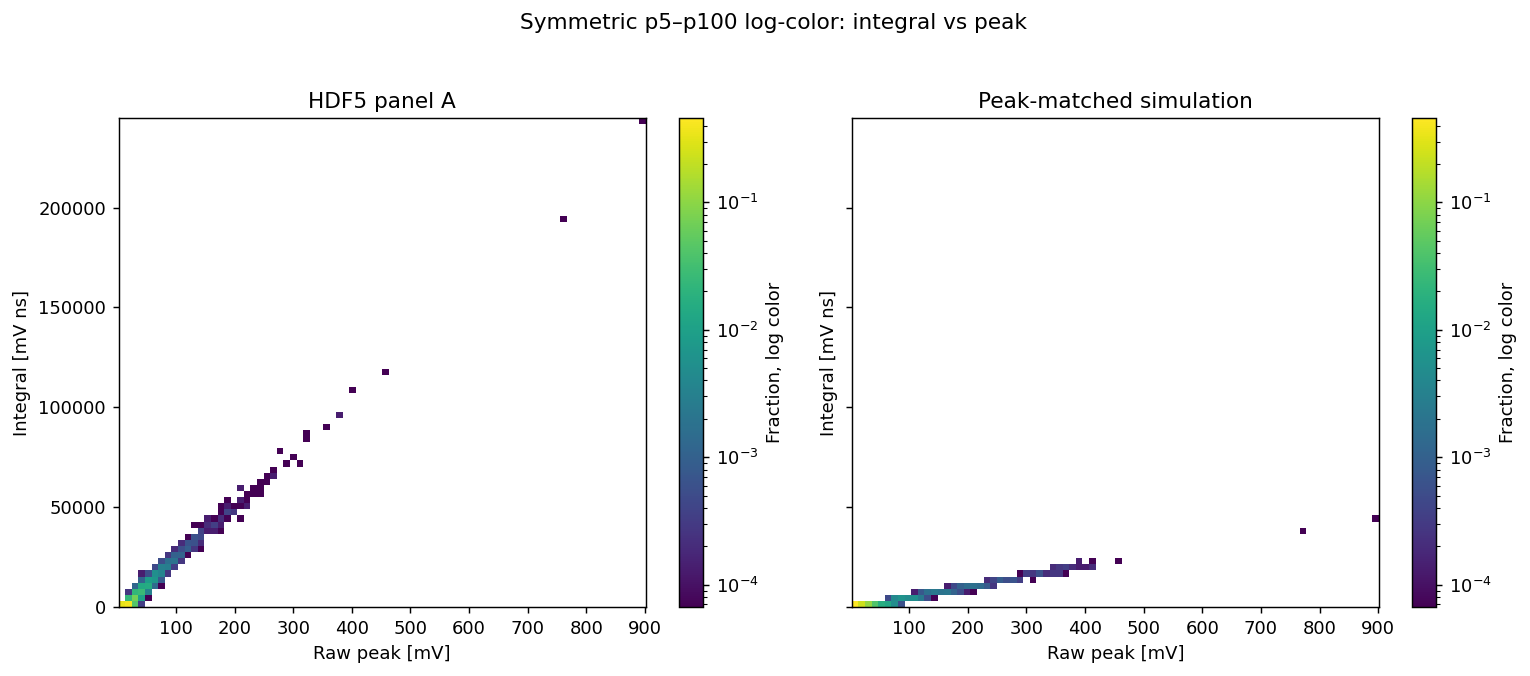


Width bin check:
First width edge: 0.0
Last width edge: 936.0
Unique width bin spacings: [8.]


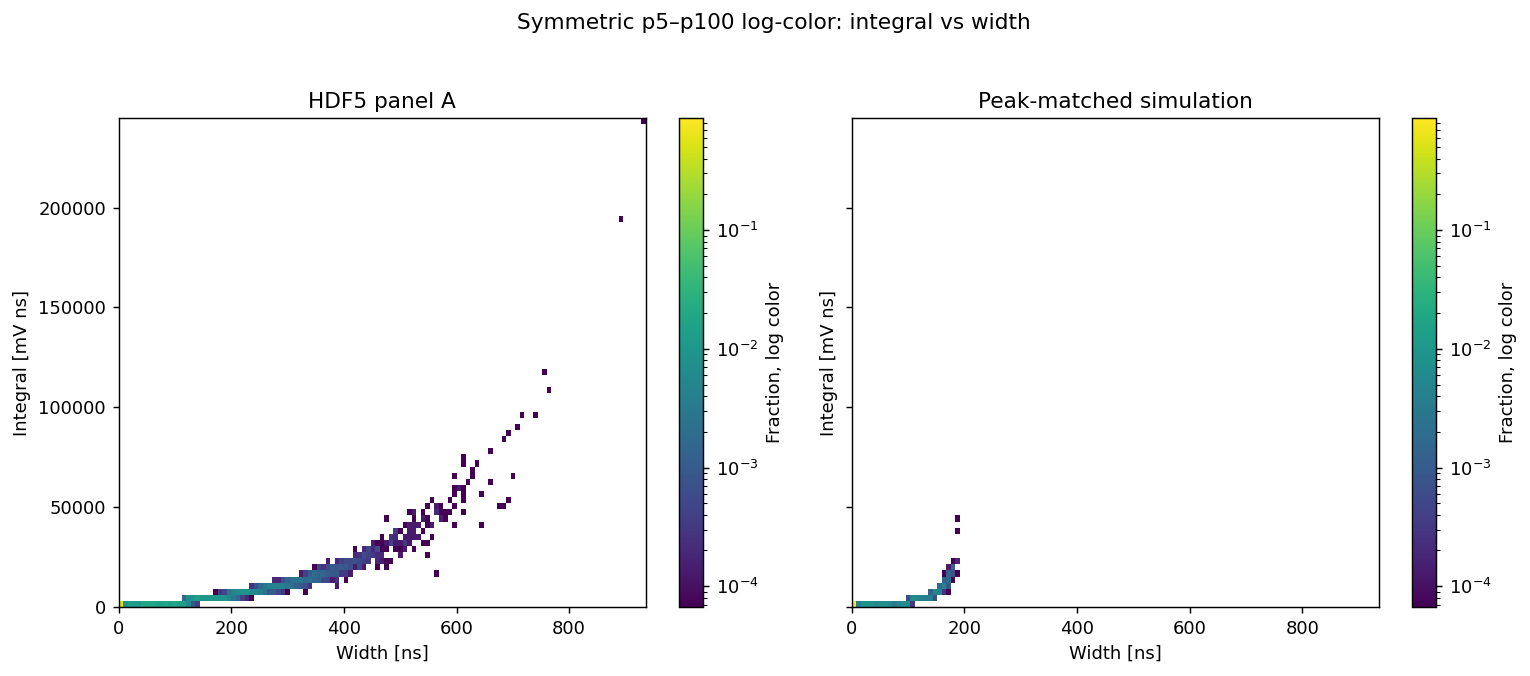


Symmetric p5-p95 visibility report:


,plot,source,finite_events,inside_plot,inside_fraction,outside_plot,outside_fraction,x_min,x_max,y_min,y_max
0,latest_h5_panel_A_hist2d_integral_vs_peak_symm...,real_h5,15000,15000,1.000000,0,0.000000,2.563477,901.092,0.0,244636.84
1,latest_h5_panel_A_hist2d_integral_vs_peak_symm...,peak_matched_simulation,15000,13750,0.916667,1250,0.083333,2.563477,901.092,0.0,244636.84
2,latest_h5_panel_A_hist2d_integral_vs_width_sym...,real_h5,15000,15000,1.000000,0,0.000000,0.000000,936.000,0.0,244636.84
3,latest_h5_panel_A_hist2d_integral_vs_width_sym...,peak_matched_simulation,15000,15000,1.000000,0,0.000000,0.000000,936.000,0.0,244636.84


Saved: C:\Users\jafar\OneDrive\Escritorio\tambo-sipm-framework\tambo-sipm-framework\outputs\tables\latest_h5_panel_A_symmetric_p5_p95_logcolor_visibility_report.csv

# HDF5 panel A: symmetric p5-p95 2D visibility note

The full-range plots are kept as diagnostic figures because they show the complete dynamic range, including low-amplitude segments and high outliers.

This additional diagnostic cell adds symmetric p5-p95 log-color 2D histograms:
- p5-p95 excludes the lower 5% and upper 5% of each plotted variable.
- The limits are computed from the combined real HDF5 + peak-matched simulation samples.
- The same axis limits are used for the real and simulated panels.
- This is only a visualization window, not a physics selection.
- Outliers are not removed from the quantitative tables.
- The width_ns axis uses fixed 8.0 ns bins, consistent with the Red Pitaya FPGA timing resolution.

Generated files:
- latest_h5_panel_A_origin_outlier_diagnostics_p5_p95.csv
- latest_h5_panel_A_hist2d_in

: 

In [ ]:
# ============================================================
# EXTRA FINAL CELL — Better 2D visibility: symmetric p5-p95 log-color
# ============================================================
#
# This cell does NOT replace the full-range diagnostics.
# It adds:
# 1. log-color 2D histograms,
# 2. symmetric central visualization window using p5-p95,
# 3. dominance diagnostics for the near-origin bin.
#
# Removed:
# - trigger-like subset
# - trigger-like thresholds
# - trigger-like plots
#
# Important:
# - p5-p95 is used only for visualization.
# - It excludes the lower 5% and upper 5% of each plotted variable.
# - It does not remove outliers from the quantitative analysis.
# - width_ns bin edges remain fixed at 8 ns.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

try:
    from IPython.display import display
except ImportError:
    display = print

OUTPUT_TABLES = Path(OUTPUT_TABLES)
OUTPUT_FIGURES = Path(OUTPUT_FIGURES)
OUTPUT_TABLES.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES.mkdir(parents=True, exist_ok=True)

PANEL_LABEL = str(PRIMARY_PANEL)
TEMPORAL_BIN_NS = 8.0

# Symmetric visualization zoom.
# This is only for visualization, not for quantitative filtering.
VIS_PERCENTILE_LOW = 5.0
VIS_PERCENTILE_HIGH = 100.0

print("Extra visibility diagnostics")
print("Panel:", PANEL_LABEL)
print("Symmetric visualization percentile range:", VIS_PERCENTILE_LOW, "to", VIS_PERCENTILE_HIGH)
print("This excludes 5% below and 5% above for each plotted variable.")
print("Width bin:", TEMPORAL_BIN_NS, "ns")


def _finite_df(df, cols):
    out = df.copy()
    mask = np.ones(len(out), dtype=bool)

    for col in cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")
        mask &= np.isfinite(out[col].to_numpy(dtype=float))

    return out.loc[mask].copy()


def _combined_limits(df1, df2, col, low, high):
    a = pd.to_numeric(df1[col], errors="coerce").to_numpy(dtype=float)
    b = pd.to_numeric(df2[col], errors="coerce").to_numpy(dtype=float)

    x = np.concatenate([a, b])
    x = x[np.isfinite(x)]

    if len(x) == 0:
        raise ValueError(f"No finite values available for column: {col}")

    lo, hi = np.percentile(x, [low, high])

    if lo == hi:
        lo -= 0.5
        hi += 0.5

    return float(lo), float(hi)


def _linear_edges(lo, hi, n=80):
    if lo == hi:
        lo -= 0.5
        hi += 0.5

    return np.linspace(lo, hi, n + 1)


def _width_edges_8ns(lo, hi):
    lo = max(0.0, TEMPORAL_BIN_NS * np.floor(lo / TEMPORAL_BIN_NS))
    hi = TEMPORAL_BIN_NS * np.ceil(hi / TEMPORAL_BIN_NS)

    if hi <= lo:
        hi = lo + TEMPORAL_BIN_NS

    edges = np.arange(lo, hi + TEMPORAL_BIN_NS, TEMPORAL_BIN_NS)

    assert np.allclose(np.diff(edges), TEMPORAL_BIN_NS), "width_ns bins are not 8 ns."

    return edges


def _hist2d_fraction(df, xcol, ycol, xedges, yedges):
    d = _finite_df(df, [xcol, ycol])

    x = d[xcol].to_numpy(dtype=float)
    y = d[ycol].to_numpy(dtype=float)

    inside = (
        (x >= xedges[0])
        & (x <= xedges[-1])
        & (y >= yedges[0])
        & (y <= yedges[-1])
    )

    # Normalize to the full finite sample, not only to the zoomed subset.
    # This preserves the interpretation: each bin is a fraction of the full finite sample.
    if len(d) == 0:
        weights = None
    else:
        weights = np.ones(inside.sum(), dtype=float) / len(d)

    hist, _, _ = np.histogram2d(
        x[inside],
        y[inside],
        bins=[xedges, yedges],
        weights=weights,
    )

    return hist, len(d), int(inside.sum())


def _plot_pair_log2d(
    real_df,
    sim_df,
    xcol,
    ycol,
    xedges,
    yedges,
    xlabel,
    ylabel,
    title,
    output_name,
):
    h_real, n_real, inside_real = _hist2d_fraction(real_df, xcol, ycol, xedges, yedges)
    h_sim, n_sim, inside_sim = _hist2d_fraction(sim_df, xcol, ycol, xedges, yedges)

    h_real_masked = np.ma.masked_where(h_real <= 0, h_real)
    h_sim_masked = np.ma.masked_where(h_sim <= 0, h_sim)

    positive_values = np.concatenate(
        [
            h_real[h_real > 0].ravel(),
            h_sim[h_sim > 0].ravel(),
        ]
    )

    if len(positive_values) == 0:
        print("No positive histogram bins for", output_name)
        return []

    vmin = float(positive_values.min())
    vmax = float(positive_values.max())

    if vmin <= 0:
        vmin = 1e-12

    if vmax <= vmin:
        vmax = vmin * 10.0

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

    m0 = axes[0].pcolormesh(
        xedges,
        yedges,
        h_real_masked.T,
        shading="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    axes[0].set_title(f"HDF5 panel {PANEL_LABEL}")
    axes[0].set_xlabel(xlabel)
    axes[0].set_ylabel(ylabel)
    fig.colorbar(m0, ax=axes[0], label="Fraction, log color")

    m1 = axes[1].pcolormesh(
        xedges,
        yedges,
        h_sim_masked.T,
        shading="auto",
        norm=LogNorm(vmin=vmin, vmax=vmax),
    )
    axes[1].set_title("Peak-matched simulation")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel(ylabel)
    fig.colorbar(m1, ax=axes[1], label="Fraction, log color")

    fig.suptitle(title, y=1.03)
    fig.tight_layout()

    output_path = OUTPUT_FIGURES / output_name
    save_figure(fig, output_path)
    plt.show()

    return [
        {
            "plot": output_name,
            "source": "real_h5",
            "finite_events": n_real,
            "inside_plot": inside_real,
            "inside_fraction": inside_real / n_real if n_real else np.nan,
            "outside_plot": n_real - inside_real,
            "outside_fraction": (n_real - inside_real) / n_real if n_real else np.nan,
            "x_min": float(xedges[0]),
            "x_max": float(xedges[-1]),
            "y_min": float(yedges[0]),
            "y_max": float(yedges[-1]),
        },
        {
            "plot": output_name,
            "source": "peak_matched_simulation",
            "finite_events": n_sim,
            "inside_plot": inside_sim,
            "inside_fraction": inside_sim / n_sim if n_sim else np.nan,
            "outside_plot": n_sim - inside_sim,
            "outside_fraction": (n_sim - inside_sim) / n_sim if n_sim else np.nan,
            "x_min": float(xedges[0]),
            "x_max": float(xedges[-1]),
            "y_min": float(yedges[0]),
            "y_max": float(yedges[-1]),
        },
    ]


# ------------------------------------------------------------
# 1. Near-origin and outlier diagnostics
# ------------------------------------------------------------

diagnostic_rows = []

for label, df in [
    ("real_h5", matched_real),
    ("peak_matched_simulation", matched_sim),
]:
    d = _finite_df(df, ["match_peak_mV", "integral_mVns", "width_ns", "rms_mV"])

    diagnostic_rows.append(
        {
            "source": label,
            "n_finite": len(d),
            "fraction_peak_below_10mV": float((d["match_peak_mV"] < 10).mean()),
            "fraction_peak_below_20mV": float((d["match_peak_mV"] < 20).mean()),
            "fraction_integral_below_1000": float((d["integral_mVns"] < 1000).mean()),
            "fraction_width_below_16ns": float((d["width_ns"] < 16).mean()),
            "p5_peak_mV": float(d["match_peak_mV"].quantile(0.05)),
            "median_peak_mV": float(d["match_peak_mV"].median()),
            "p95_peak_mV": float(d["match_peak_mV"].quantile(0.95)),
            "max_peak_mV": float(d["match_peak_mV"].max()),
            "p5_integral_mVns": float(d["integral_mVns"].quantile(0.05)),
            "median_integral_mVns": float(d["integral_mVns"].median()),
            "p95_integral_mVns": float(d["integral_mVns"].quantile(0.95)),
            "max_integral_mVns": float(d["integral_mVns"].max()),
            "p5_width_ns": float(d["width_ns"].quantile(0.05)),
            "median_width_ns": float(d["width_ns"].median()),
            "p95_width_ns": float(d["width_ns"].quantile(0.95)),
            "max_width_ns": float(d["width_ns"].max()),
        }
    )

dominance_table = pd.DataFrame(diagnostic_rows)

dominance_path = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_origin_outlier_diagnostics_p5_p95.csv"
)

dominance_table.to_csv(dominance_path, index=False)

print("\nNear-origin / outlier diagnostics:")
display(dominance_table)
print("Saved:", dominance_path)


# ------------------------------------------------------------
# 2. Symmetric p5-p95 log-color plot: integral vs peak
# ------------------------------------------------------------

report_rows = []

peak_lo, peak_hi = _combined_limits(
    matched_real,
    matched_sim,
    "match_peak_mV",
    VIS_PERCENTILE_LOW,
    VIS_PERCENTILE_HIGH,
)

integral_lo, integral_hi = _combined_limits(
    matched_real,
    matched_sim,
    "integral_mVns",
    VIS_PERCENTILE_LOW,
    VIS_PERCENTILE_HIGH,
)

# Force lower bounds to zero where physically useful.
peak_lo = max(0.0, peak_lo)
integral_lo = max(0.0, integral_lo)

peak_edges = _linear_edges(peak_lo, peak_hi, n=80)
integral_edges = _linear_edges(integral_lo, integral_hi, n=80)

report_rows.extend(
    _plot_pair_log2d(
        matched_real,
        matched_sim,
        xcol="match_peak_mV",
        ycol="integral_mVns",
        xedges=peak_edges,
        yedges=integral_edges,
        xlabel="Raw peak [mV]",
        ylabel="Integral [mV ns]",
        title=(
            f"Symmetric p{VIS_PERCENTILE_LOW:.0f}–p{VIS_PERCENTILE_HIGH:.0f} "
            "log-color: integral vs peak"
        ),
        output_name=(
            f"latest_h5_panel_{PANEL_LABEL}"
            "_hist2d_integral_vs_peak_symmetric_p5_p95_logcolor.png"
        ),
    )
)


# ------------------------------------------------------------
# 3. Symmetric p5-p95 log-color plot: integral vs width
# ------------------------------------------------------------
# IMPORTANT:
# width_ns bin edges are forced to exactly 8 ns.

width_lo, width_hi = _combined_limits(
    matched_real,
    matched_sim,
    "width_ns",
    VIS_PERCENTILE_LOW,
    VIS_PERCENTILE_HIGH,
)

integral_lo_w, integral_hi_w = _combined_limits(
    matched_real,
    matched_sim,
    "integral_mVns",
    VIS_PERCENTILE_LOW,
    VIS_PERCENTILE_HIGH,
)

width_lo = max(0.0, width_lo)
integral_lo_w = max(0.0, integral_lo_w)

width_edges = _width_edges_8ns(width_lo, width_hi)
integral_edges_w = _linear_edges(integral_lo_w, integral_hi_w, n=80)

print("\nWidth bin check:")
print("First width edge:", width_edges[0])
print("Last width edge:", width_edges[-1])
print("Unique width bin spacings:", np.unique(np.diff(width_edges)))

report_rows.extend(
    _plot_pair_log2d(
        matched_real,
        matched_sim,
        xcol="width_ns",
        ycol="integral_mVns",
        xedges=width_edges,
        yedges=integral_edges_w,
        xlabel="Width [ns]",
        ylabel="Integral [mV ns]",
        title=(
            f"Symmetric p{VIS_PERCENTILE_LOW:.0f}–p{VIS_PERCENTILE_HIGH:.0f} "
            "log-color: integral vs width"
        ),
        output_name=(
            f"latest_h5_panel_{PANEL_LABEL}"
            "_hist2d_integral_vs_width_symmetric_p5_p95_logcolor.png"
        ),
    )
)


# ------------------------------------------------------------
# 4. Save p5-p95 visibility report
# ------------------------------------------------------------

visibility_report = pd.DataFrame(report_rows)

visibility_report_path = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_symmetric_p5_p95_logcolor_visibility_report.csv"
)

visibility_report.to_csv(visibility_report_path, index=False)

print("\nSymmetric p5-p95 visibility report:")
display(visibility_report)
print("Saved:", visibility_report_path)


# ------------------------------------------------------------
# 5. Interpretation note
# ------------------------------------------------------------

note = f"""
# HDF5 panel {PANEL_LABEL}: symmetric p5-p95 2D visibility note

The full-range plots are kept as diagnostic figures because they show the complete dynamic range, including low-amplitude segments and high outliers.

This additional diagnostic cell adds symmetric p5-p95 log-color 2D histograms:
- p5-p95 excludes the lower 5% and upper 5% of each plotted variable.
- The limits are computed from the combined real HDF5 + peak-matched simulation samples.
- The same axis limits are used for the real and simulated panels.
- This is only a visualization window, not a physics selection.
- Outliers are not removed from the quantitative tables.
- The width_ns axis uses fixed {TEMPORAL_BIN_NS} ns bins, consistent with the Red Pitaya FPGA timing resolution.

Generated files:
- {dominance_path.name}
- latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_peak_symmetric_p5_p95_logcolor.png
- latest_h5_panel_{PANEL_LABEL}_hist2d_integral_vs_width_symmetric_p5_p95_logcolor.png
- {visibility_report_path.name}

Interpretation:
If the real HDF5 distribution still shows larger integrals and widths than the matched simulation inside this symmetric p5-p95 window, the discrepancy is not only due to outliers. It indicates that the current simulation reproduces amplitude better than the temporal morphology of the real pulses.
"""

note_path = (
    OUTPUT_TABLES
    / f"latest_h5_panel_{PANEL_LABEL}_symmetric_p5_p95_2d_visibility_note.md"
)

note_path.write_text(note, encoding="utf-8")

print(note)
print("Saved:", note_path)